
<h1 style="text-align: center; font-family: 'Lucida Handwriting', cursive; color: #d4af37; font-size: 48px;">
  Notebook by: Amro Kahla
</h1>
<h2 style="text-align: center; font-family: 'Garamond', sans-serif; color: #87CEEB;">
  Anomaly Detection
</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import KFold
from sklearn.neighbors import LocalOutlierFactor
import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## Load Data & Quick View

In [3]:
df = pd.read_csv("bank_transactions_data_2.csv")
print(f"Dataset shape: {df.shape}")

Dataset shape: (2512, 16)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [5]:
print(df.describe().T)

                      count         mean          std     min       25%  \
TransactionAmount    2512.0   297.593778   291.946243    0.26    81.885   
CustomerAge          2512.0    44.673965    17.792198   18.00    27.000   
TransactionDuration  2512.0   119.643312    69.963757   10.00    63.000   
LoginAttempts        2512.0     1.124602     0.602662    1.00     1.000   
AccountBalance       2512.0  5114.302966  3900.942499  101.25  1504.370   

                         50%        75%       max  
TransactionAmount     211.14   414.5275   1919.11  
CustomerAge            45.00    59.0000     80.00  
TransactionDuration   112.50   161.0000    300.00  
LoginAttempts           1.00     1.0000      5.00  
AccountBalance       4735.51  7678.8200  14977.99  


In [6]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Values'] > 0])

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


In [7]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


## EDA With Visualization

In [8]:
df_eda = df.copy()

Convert date columns to datetime

In [9]:
df_eda["TransactionDate"] = pd.to_datetime(df_eda["TransactionDate"])
if "PreviousTransactionDate" in df_eda.columns:
    df_eda["PreviousTransactionDate"] = pd.to_datetime(df_eda["PreviousTransactionDate"])

In [10]:
df_eda["Hour"] = df_eda["TransactionDate"].dt.hour
df_eda["DayOfWeek"] = df_eda["TransactionDate"].dt.dayofweek
df_eda["Weekend"] = df_eda["DayOfWeek"].apply(lambda x: 1 if x >= 5 else 0)
df_eda["Month"] = df_eda["TransactionDate"].dt.month

In [11]:
if "PreviousTransactionDate" in df_eda.columns:
    df_eda["TimeSinceLastTx"] = (df_eda["TransactionDate"] - df_eda["PreviousTransactionDate"]).dt.total_seconds() / 3600
    df_eda["TimeSinceLastTx"].fillna(df_eda["TimeSinceLastTx"].median(), inplace=True)

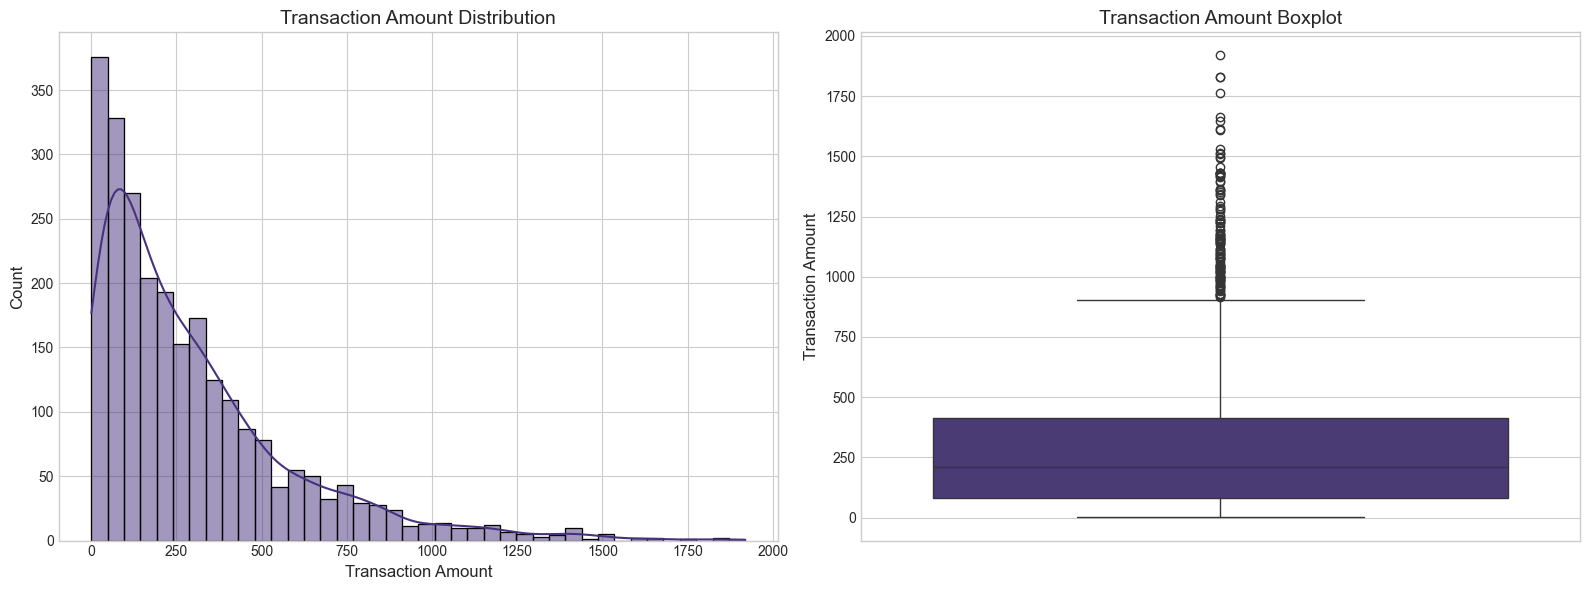

In [12]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_eda['TransactionAmount'], kde=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_eda['TransactionAmount'])
plt.title('Transaction Amount Boxplot')
plt.ylabel('Transaction Amount')
plt.tight_layout()
plt.show()

Z-score for identifying outliers in transaction amount

In [13]:
z_scores = stats.zscore(df_eda['TransactionAmount'])
df_eda['Amount_Z_Score'] = z_scores
print(f"\nOutliers (|z-score| > 3): {len(df_eda[abs(df_eda['Amount_Z_Score']) > 3])}")


Outliers (|z-score| > 3): 48


Analyze transactions by hour

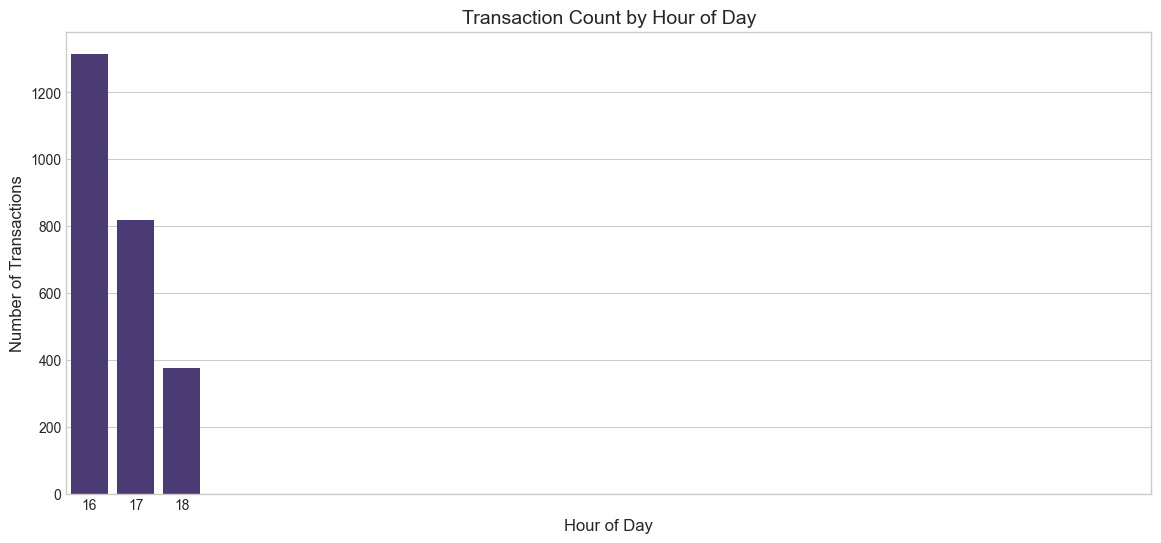

In [14]:
plt.figure(figsize=(14, 6))
hour_counts = df_eda.groupby('Hour').size()
sns.barplot(x=hour_counts.index, y=hour_counts.values)
plt.title('Transaction Count by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))
plt.show()

Analyze transactions by day of week

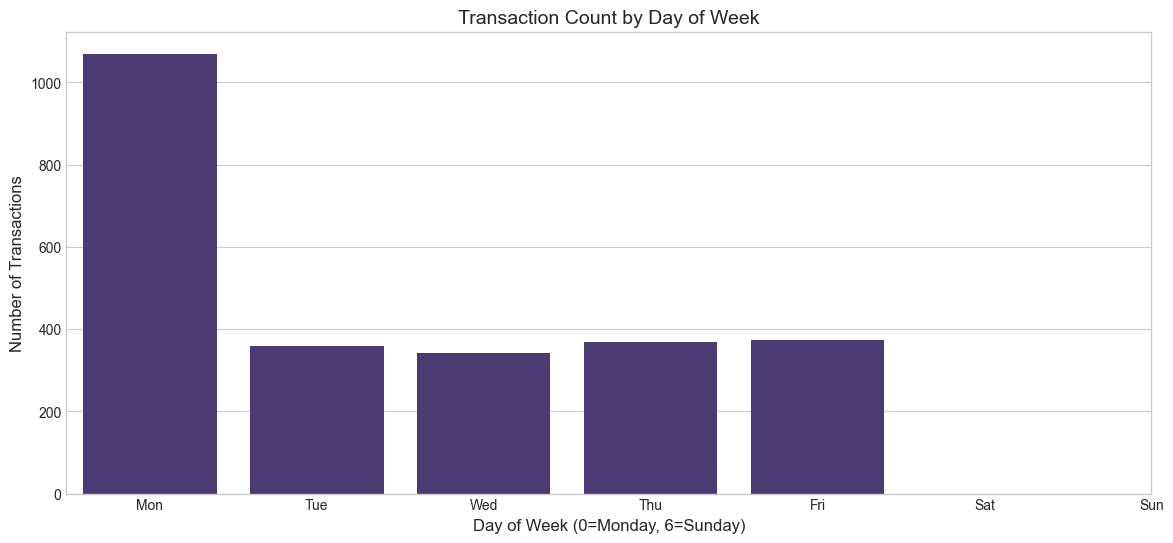

In [15]:
plt.figure(figsize=(14, 6))
day_counts = df_eda.groupby('DayOfWeek').size()
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title('Transaction Count by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

Transaction type distribution

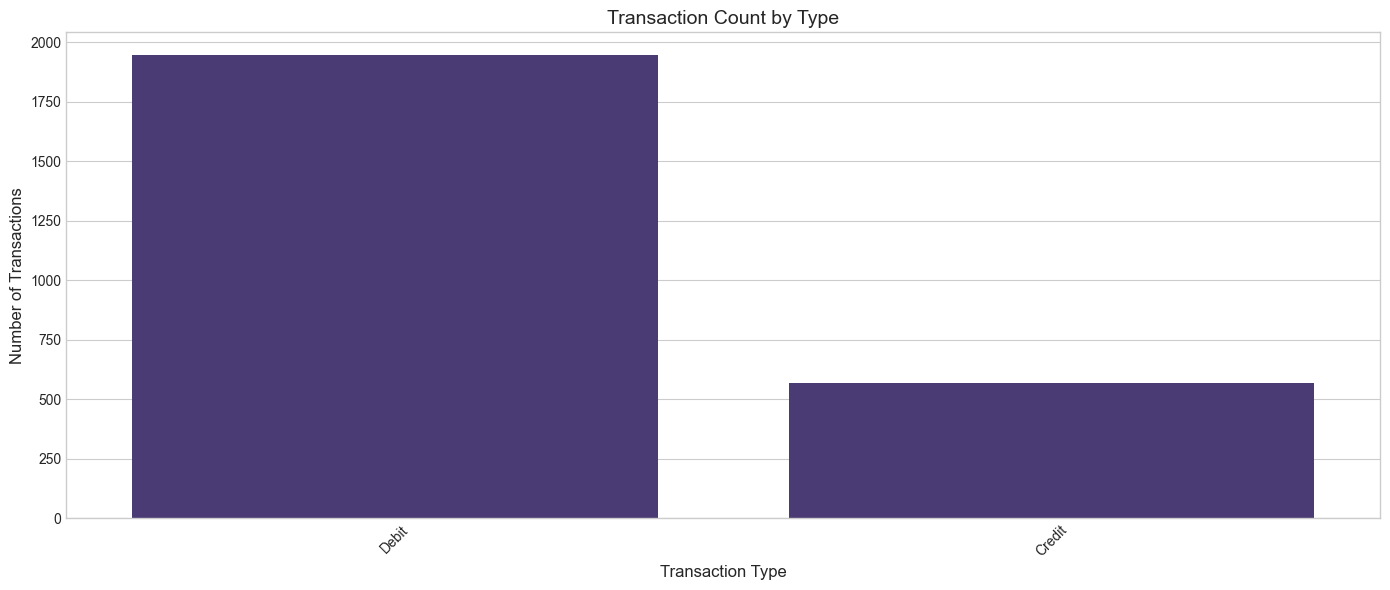

In [16]:
plt.figure(figsize=(14, 6))
tx_counts = df_eda.groupby('TransactionType').size().sort_values(ascending=False)
sns.barplot(x=tx_counts.index, y=tx_counts.values)
plt.title('Transaction Count by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Location distribution

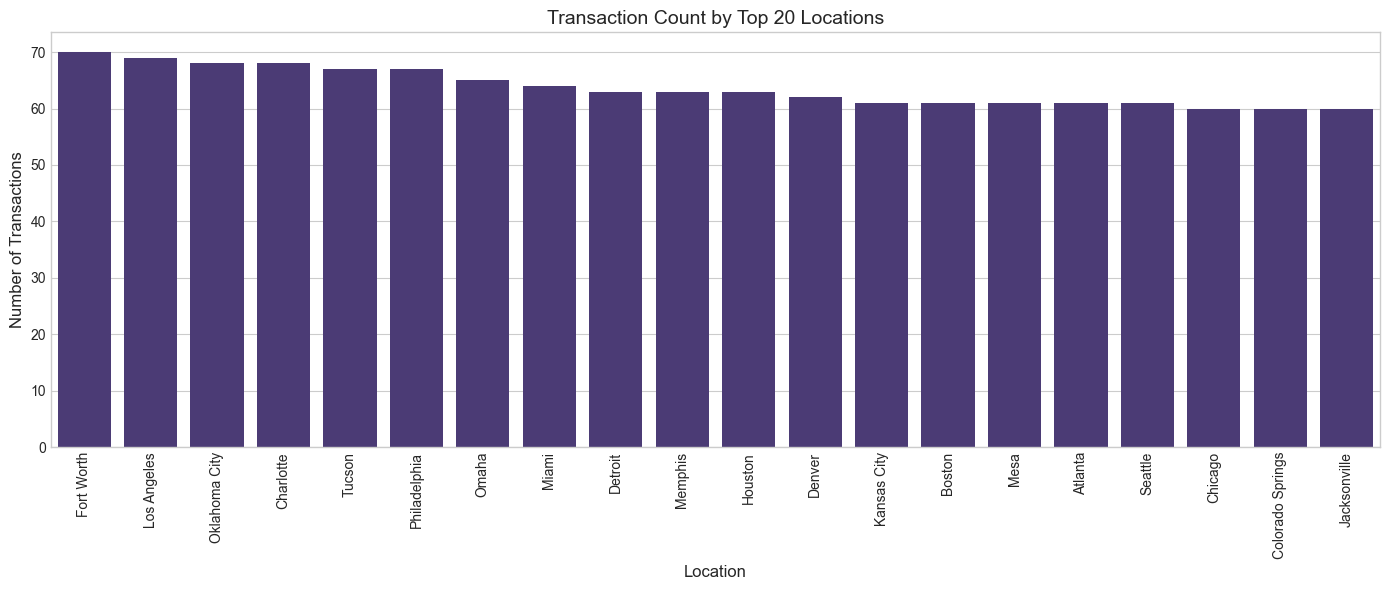

In [17]:
plt.figure(figsize=(14, 6))
loc_counts = df_eda.groupby('Location').size().sort_values(ascending=False).head(20)
sns.barplot(x=loc_counts.index, y=loc_counts.values)
plt.title('Transaction Count by Top 20 Locations')
plt.xlabel('Location')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Channel distribution

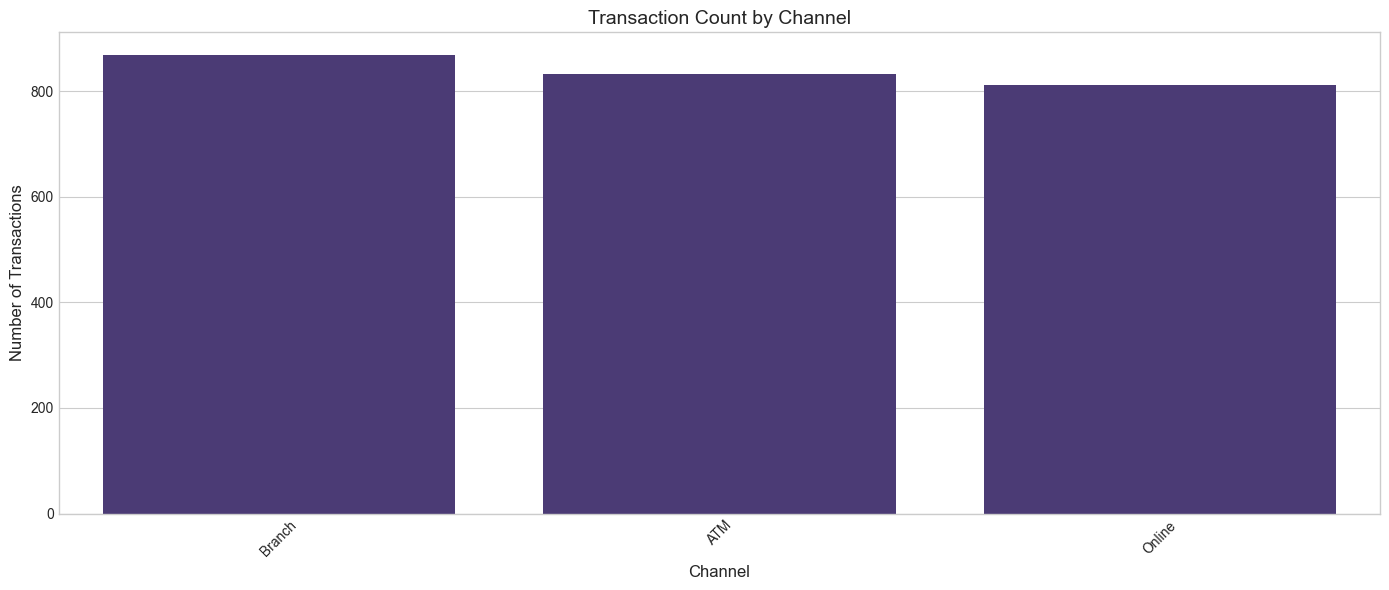

In [18]:
plt.figure(figsize=(14, 6))
channel_counts = df_eda.groupby('Channel').size().sort_values(ascending=False)
sns.barplot(x=channel_counts.index, y=channel_counts.values)
plt.title('Transaction Count by Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average transaction amount by type

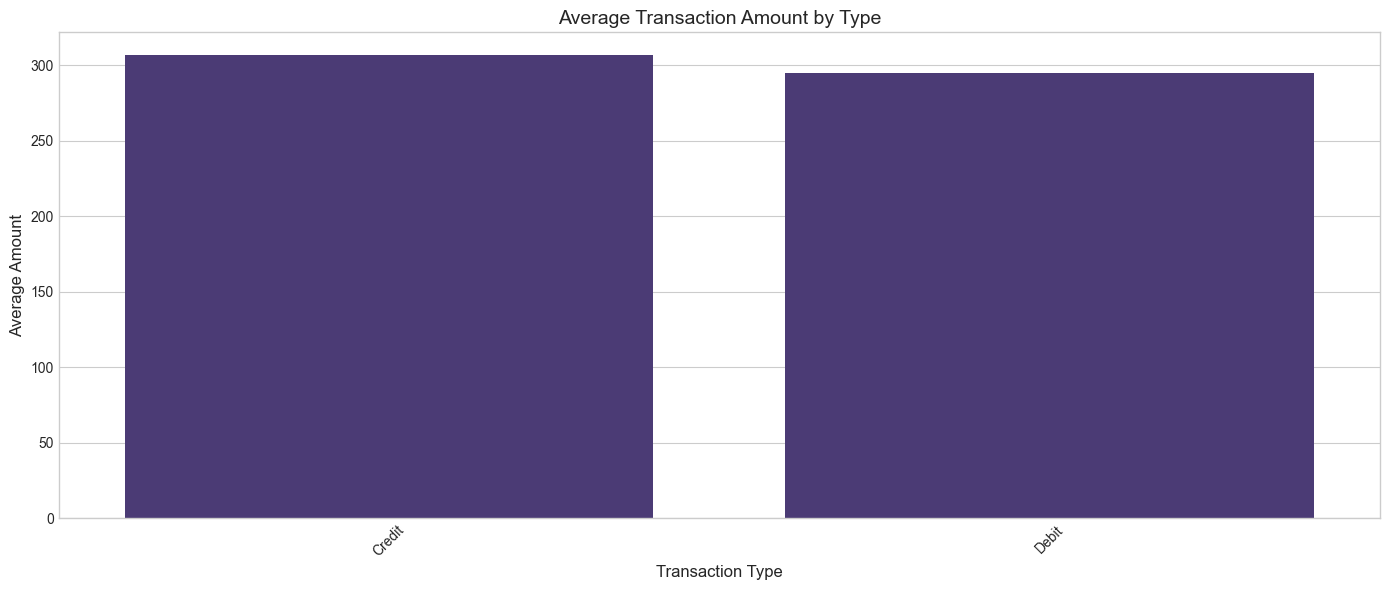

In [19]:
plt.figure(figsize=(14, 6))
avg_amounts = df_eda.groupby('TransactionType')['TransactionAmount'].mean().sort_values(ascending=False)
sns.barplot(x=avg_amounts.index, y=avg_amounts.values)
plt.title('Average Transaction Amount by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Average Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Correlation analysis

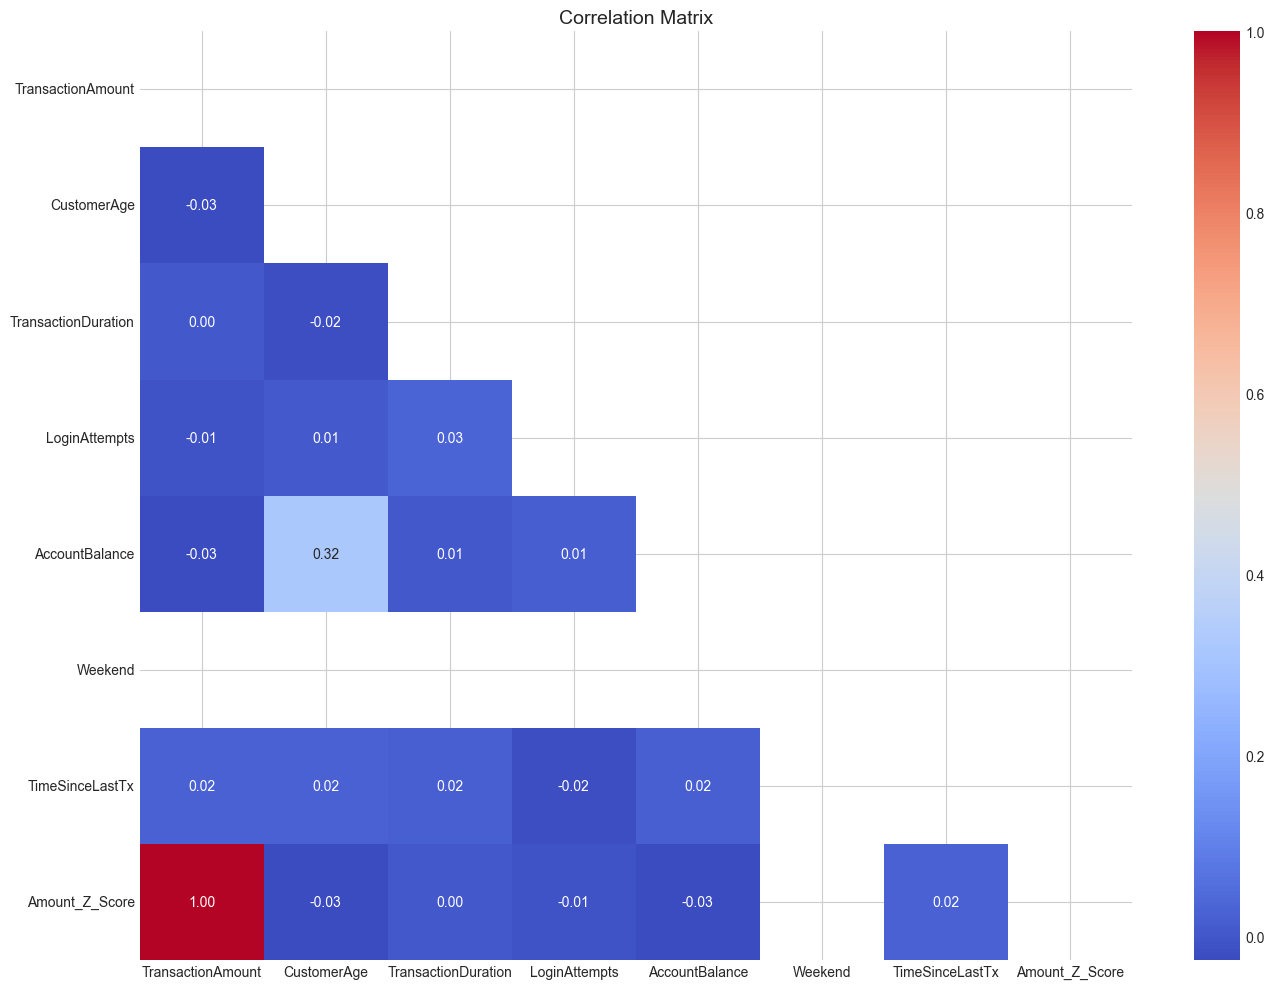

In [20]:
numeric_df = df_eda.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(14, 10))
correlation = numeric_df.corr()
mask = np.triu(correlation)
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', mask=mask)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Feature Engineering

In [21]:
df_model = df_eda.copy()

In [22]:
if "TransactionID" in df_model.columns:
    df_model.drop("TransactionID", axis=1, inplace=True)
if "AccountID" in df_model.columns:
    df_model.drop("AccountID", axis=1, inplace=True)
if "IP Address" in df_model.columns:
    df_model.drop("IP Address", axis=1, inplace=True)
if "TransactionDate" in df_model.columns:
    df_model.drop("TransactionDate", axis=1, inplace=True)
if "PreviousTransactionDate" in df_model.columns:
    df_model.drop("PreviousTransactionDate", axis=1, inplace=True)
if "Amount_Z_Score" in df_model.columns:
    df_model.drop("Amount_Z_Score", axis=1, inplace=True)

### Feature creation

Calculate transaction amount / average transaction amount for that transaction type

In [23]:
avg_tx_amount_by_type = df_model.groupby('TransactionType')['TransactionAmount'].transform('mean')
df_model['Amount_to_AvgByType_Ratio'] = df_model['TransactionAmount'] / avg_tx_amount_by_type

Transaction frequency by device

In [24]:
device_tx_count = df_model.groupby('DeviceID').size().reset_index(name='DeviceTxCount')
df_model = pd.merge(df_model, device_tx_count, on='DeviceID', how='left')

Prepare categorical and numerical features

In [25]:
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()

We need to convert categorical columns to numerical for modeling

In [26]:
le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

In [27]:
print(f"Final dataset shape: {df_model.shape}")
print(f"Features: {', '.join(df_model.columns.tolist())}")

Final dataset shape: (2512, 18)
Features: TransactionAmount, TransactionType, Location, DeviceID, MerchantID, Channel, CustomerAge, CustomerOccupation, TransactionDuration, LoginAttempts, AccountBalance, Hour, DayOfWeek, Weekend, Month, TimeSinceLastTx, Amount_to_AvgByType_Ratio, DeviceTxCount


### Scale the features

In [28]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)
df_scaled_df = pd.DataFrame(df_scaled, columns=df_model.columns)

## Visualization

In [29]:
n_components = min(10, len(df_model.columns))
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(df_scaled)

In [30]:
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

Explained variance ratio: [0.12137032 0.11684163 0.11042045 0.07158318 0.06318671 0.06207726
 0.06080135 0.05923777 0.05718923 0.05675363]
Cumulative explained variance: 0.7795


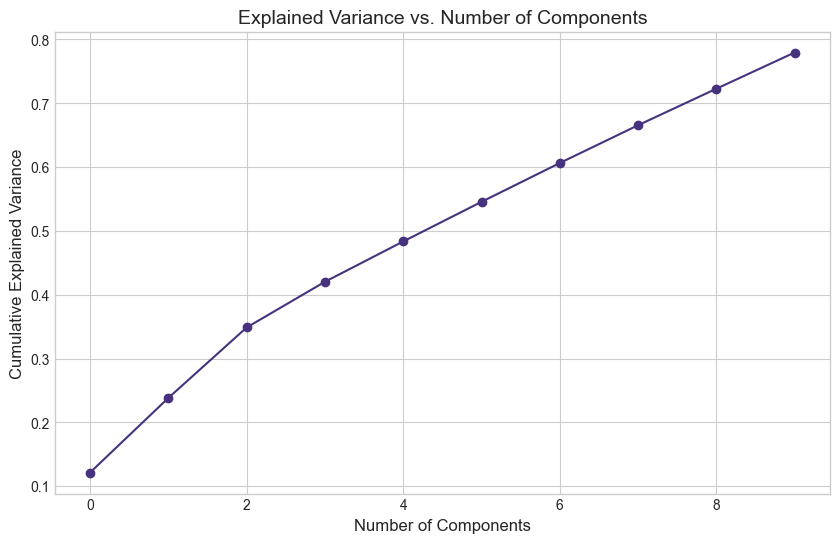

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()


Applying t-SNE for visualization...


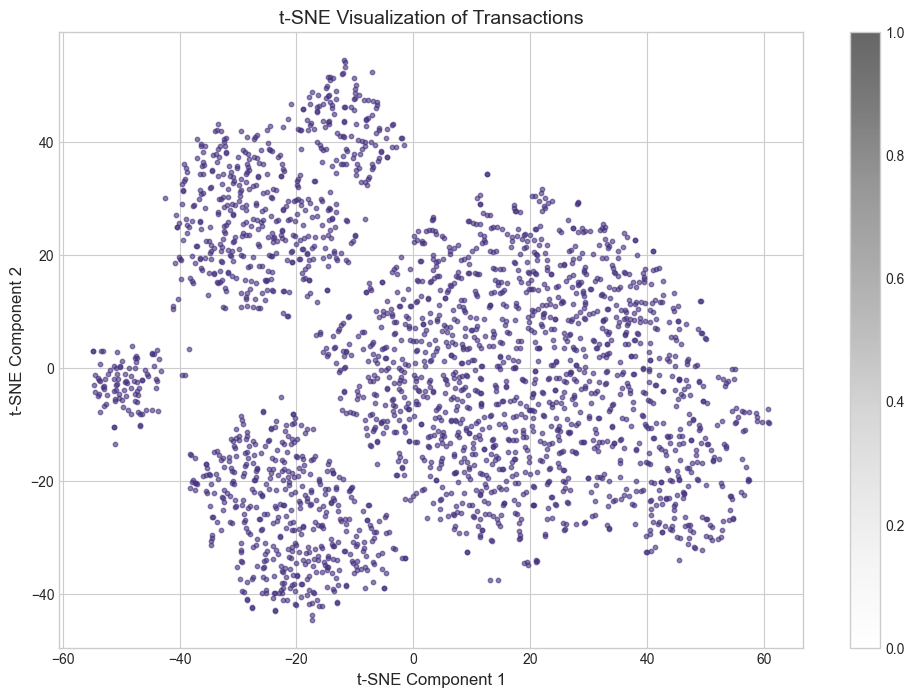

In [32]:
print("\nApplying t-SNE for visualization...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(df_scaled)

plt.figure(figsize=(12, 8))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=10, alpha=0.6)
plt.title('t-SNE Visualization of Transactions')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar()
plt.show()

## Multiple Anomaly Detection Methods

### Isolation Forest

In [33]:
param_grid = {
    'n_estimators': [100, 200],
    'contamination': [0.01, 0.02, 0.05],
    'max_samples': [100, 'auto']
}

In [34]:
iso_forest = IsolationForest(random_state=42)
grid_search = GridSearchCV(
    estimator=iso_forest,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=0
)
grid_search.fit(df_scaled)

GridSearchCV(cv=3, estimator=IsolationForest(random_state=42),
             param_grid={'contamination': [0.01, 0.02, 0.05],
                         'max_samples': [100, 'auto'],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error')

In [35]:
print(f"Best Isolation Forest parameters: {grid_search.best_params_}")
best_iso_forest = grid_search.best_estimator_

Best Isolation Forest parameters: {'contamination': 0.01, 'max_samples': 100, 'n_estimators': 100}


In [36]:
df_model['IF_Anomaly'] = best_iso_forest.predict(df_scaled)
df_model['IF_Score'] = best_iso_forest.decision_function(df_scaled)

In [37]:
df_model['IF_Anomaly'] = df_model['IF_Anomaly'].map({1: 0, -1: 1})

### DBSCAN

Find optimal eps using KNN distance plot


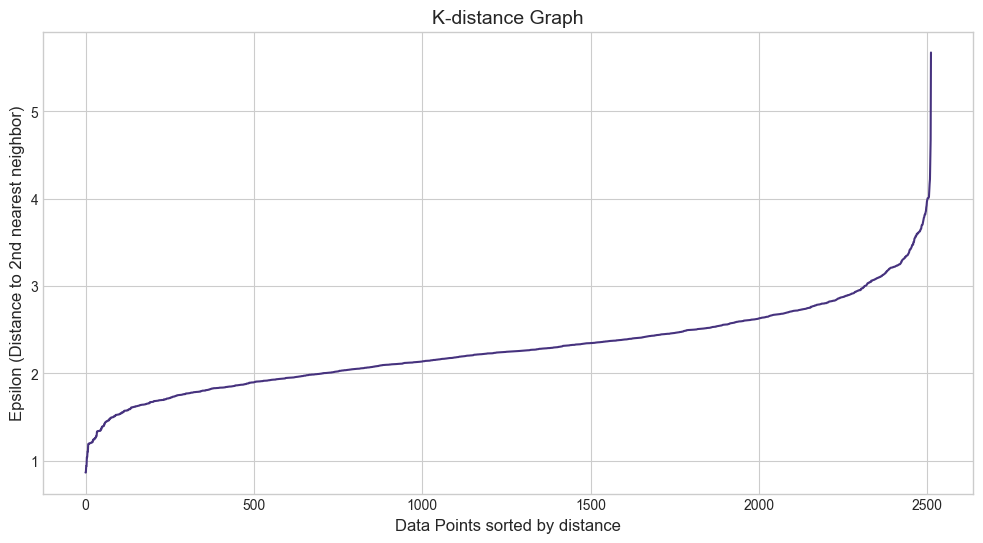

In [38]:
nn = NearestNeighbors(n_neighbors=2)
nn.fit(df_scaled)
distances, indices = nn.kneighbors(df_scaled)
distances = np.sort(distances[:, 1])

plt.figure(figsize=(12, 6))
plt.plot(range(len(distances)), distances)
plt.title('K-distance Graph')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (Distance to 2nd nearest neighbor)')
plt.grid(True)
plt.show()

In [39]:
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 15, 20]

best_silhouette = -1
best_eps = None
best_min_samples = None

print("\nFinding optimal DBSCAN parameters...")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(df_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1 and not all(l == -1 for l in labels):
            try:
                score = silhouette_score(df_scaled, labels)
                print(f"eps={eps}, min_samples={min_samples}, n_clusters={n_clusters}, silhouette={score:.4f}")
                if score > best_silhouette:
                    best_silhouette = score
                    best_eps = eps
                    best_min_samples = min_samples
            except:
                continue

print(f"\nBest DBSCAN parameters: eps={best_eps}, min_samples={best_min_samples}, silhouette={best_silhouette:.4f}")


Finding optimal DBSCAN parameters...
eps=2.0, min_samples=5, n_clusters=14, silhouette=-0.2546
eps=2.5, min_samples=5, n_clusters=13, silhouette=-0.1754
eps=2.5, min_samples=10, n_clusters=2, silhouette=-0.0543
eps=3.0, min_samples=20, n_clusters=2, silhouette=0.0075

Best DBSCAN parameters: eps=3.0, min_samples=20, silhouette=0.0075


In [40]:
dbscan = DBSCAN(eps=best_eps if best_eps else 2.5, min_samples=best_min_samples if best_min_samples else 10)
df_model['DBSCAN_Label'] = dbscan.fit_predict(df_scaled)

In [41]:
df_model['DBSCAN_Anomaly'] = df_model['DBSCAN_Label'].apply(lambda x: 1 if x == -1 else 0)

### One-Class SVM

In [42]:
ocsvm = OneClassSVM(nu=0.05, kernel="rbf", gamma='auto')
df_model['OCSVM_Anomaly'] = ocsvm.fit_predict(df_scaled)
df_model['OCSVM_Score'] = ocsvm.decision_function(df_scaled)

In [43]:
df_model['OCSVM_Anomaly'] = df_model['OCSVM_Anomaly'].map({1: 0, -1: 1})

## Model Evaluations

In [44]:
print("\nAnomaly counts by each method:")
print(f"Isolation Forest Anomalies: {df_model['IF_Anomaly'].sum()} ({df_model['IF_Anomaly'].mean()*100:.2f}%)")
print(f"DBSCAN Anomalies: {df_model['DBSCAN_Anomaly'].sum()} ({df_model['DBSCAN_Anomaly'].mean()*100:.2f}%)")
print(f"One-Class SVM Anomalies: {df_model['OCSVM_Anomaly'].sum()} ({df_model['OCSVM_Anomaly'].mean()*100:.2f}%)")


Anomaly counts by each method:
Isolation Forest Anomalies: 26 (1.04%)
DBSCAN Anomalies: 639 (25.44%)
One-Class SVM Anomalies: 132 (5.25%)


In [45]:
df_model['Ensemble_Anomaly'] = ((df_model['IF_Anomaly'] + df_model['DBSCAN_Anomaly'] + df_model['OCSVM_Anomaly']) >= 2).astype(int)
print(f"Ensemble Anomalies (majority vote): {df_model['Ensemble_Anomaly'].sum()} ({df_model['Ensemble_Anomaly'].mean()*100:.2f}%)")

Ensemble Anomalies (majority vote): 110 (4.38%)


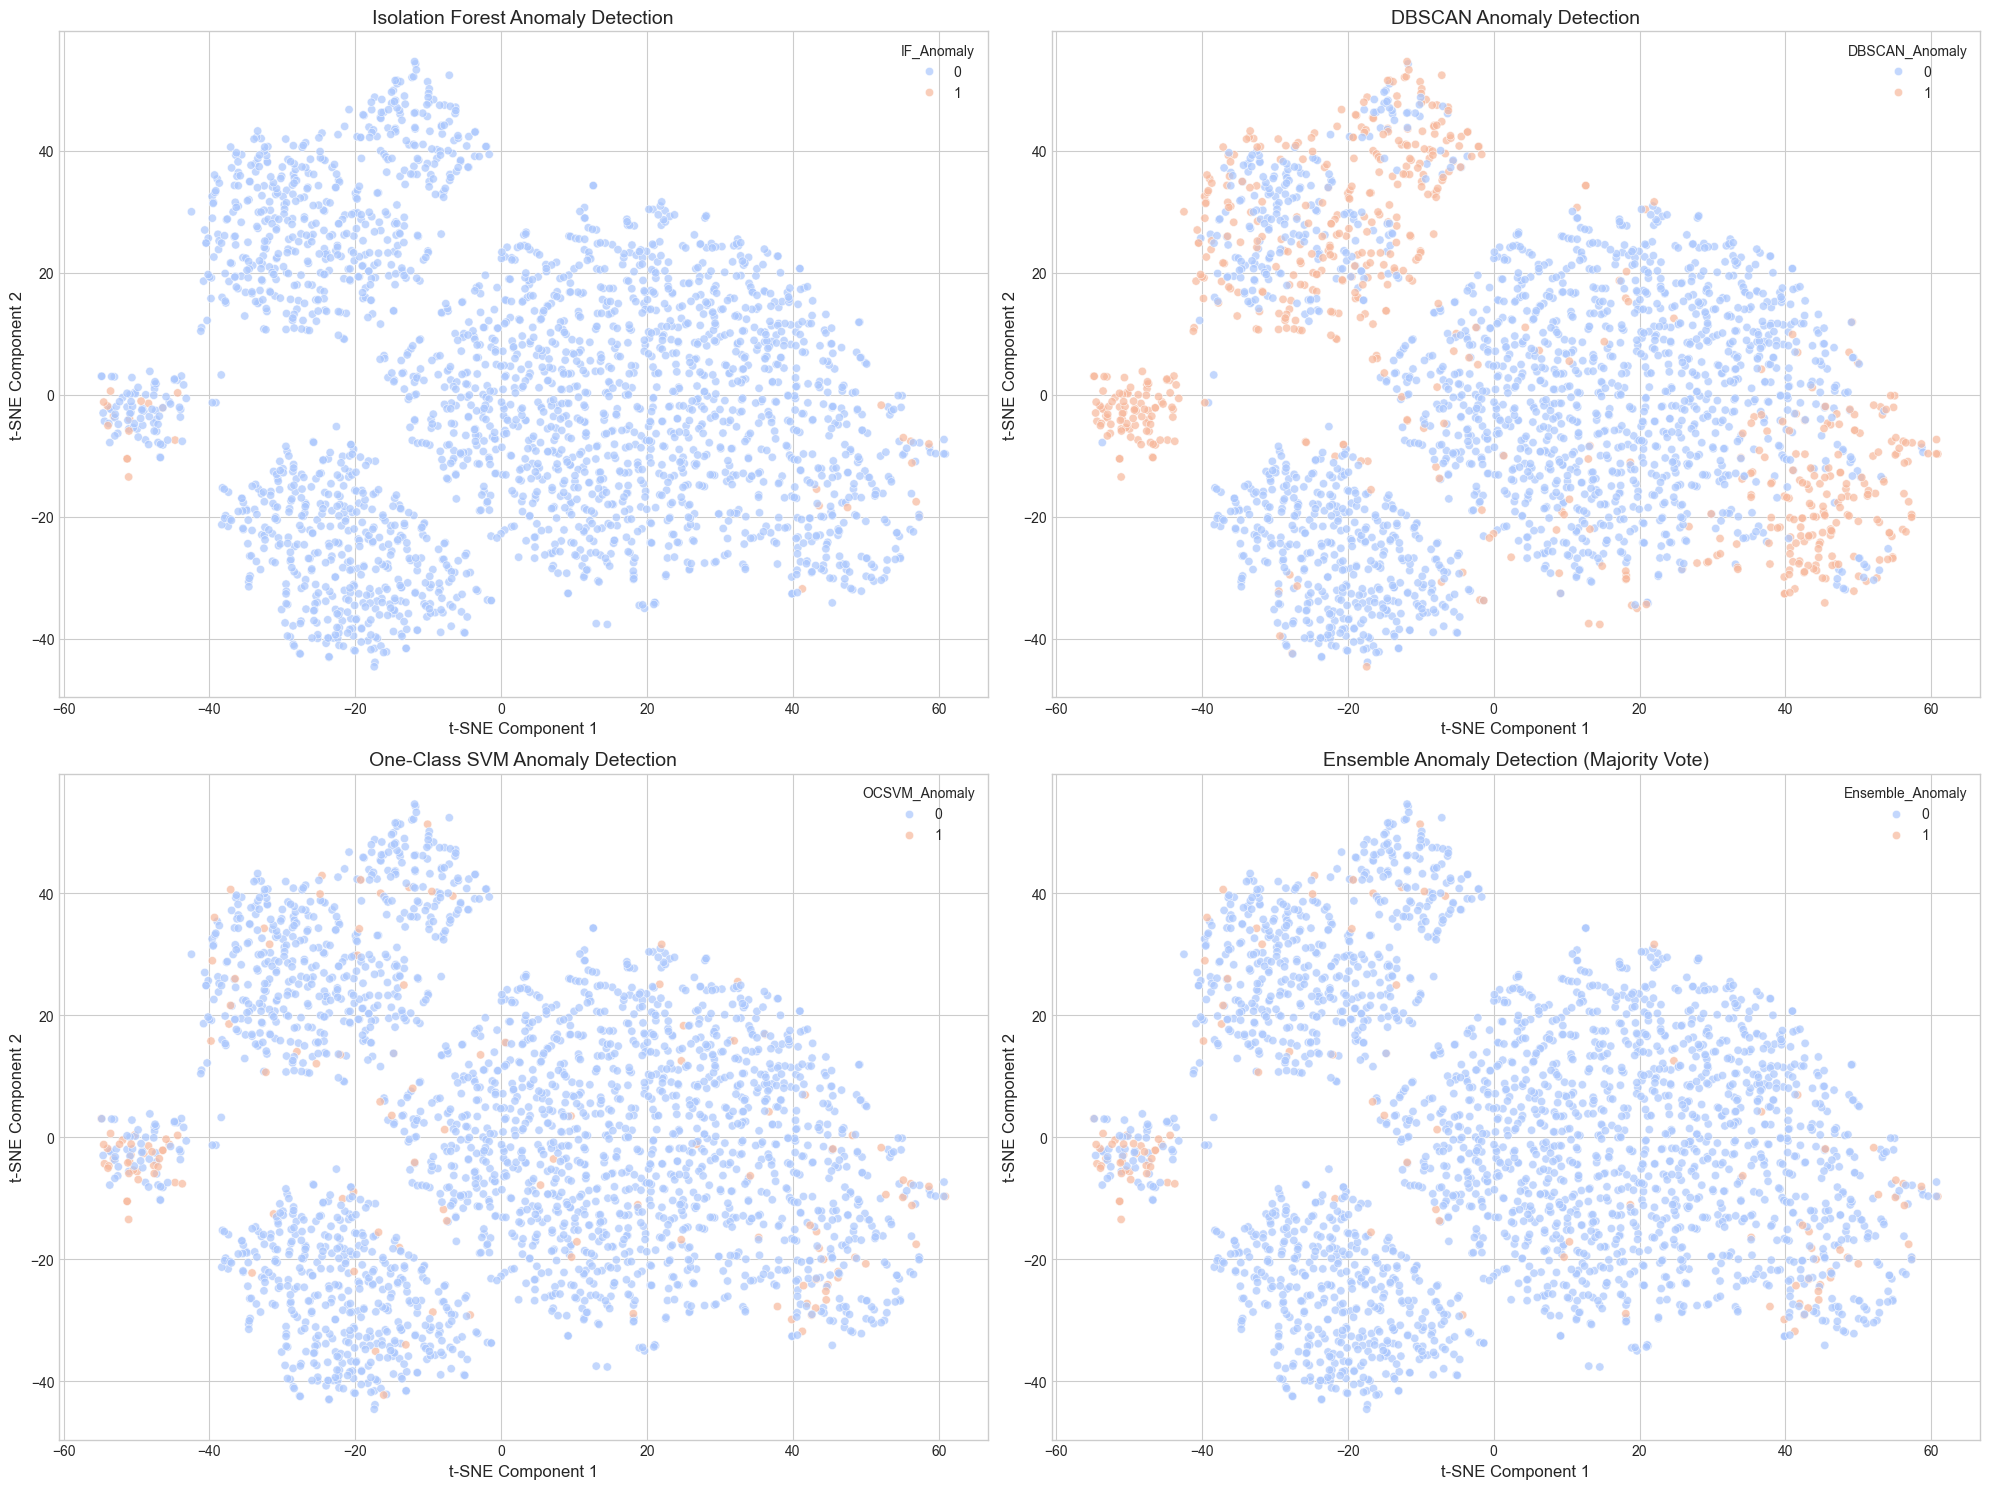

In [46]:
plt.figure(figsize=(20, 15))

plt.subplot(2, 2, 1)
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=df_model['IF_Anomaly'], palette='coolwarm', alpha=0.7)
plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.subplot(2, 2, 2)
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=df_model['DBSCAN_Anomaly'], palette='coolwarm', alpha=0.7)
plt.title('DBSCAN Anomaly Detection')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.subplot(2, 2, 3)
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=df_model['OCSVM_Anomaly'], palette='coolwarm', alpha=0.7)
plt.title('One-Class SVM Anomaly Detection')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.subplot(2, 2, 4)
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=df_model['Ensemble_Anomaly'], palette='coolwarm', alpha=0.7)
plt.title('Ensemble Anomaly Detection (Majority Vote)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.tight_layout()
plt.show()

## Anomaly Charchterization

In [47]:
anomalies = df_model[df_model['Ensemble_Anomaly'] == 1]
normal = df_model[df_model['Ensemble_Anomaly'] == 0]

print(f"\nTotal anomalies: {len(anomalies)}")
print(f"Anomaly percentage: {len(anomalies) / len(df_model) * 100:.2f}%")


Total anomalies: 110
Anomaly percentage: 4.38%


Compare transaction amounts

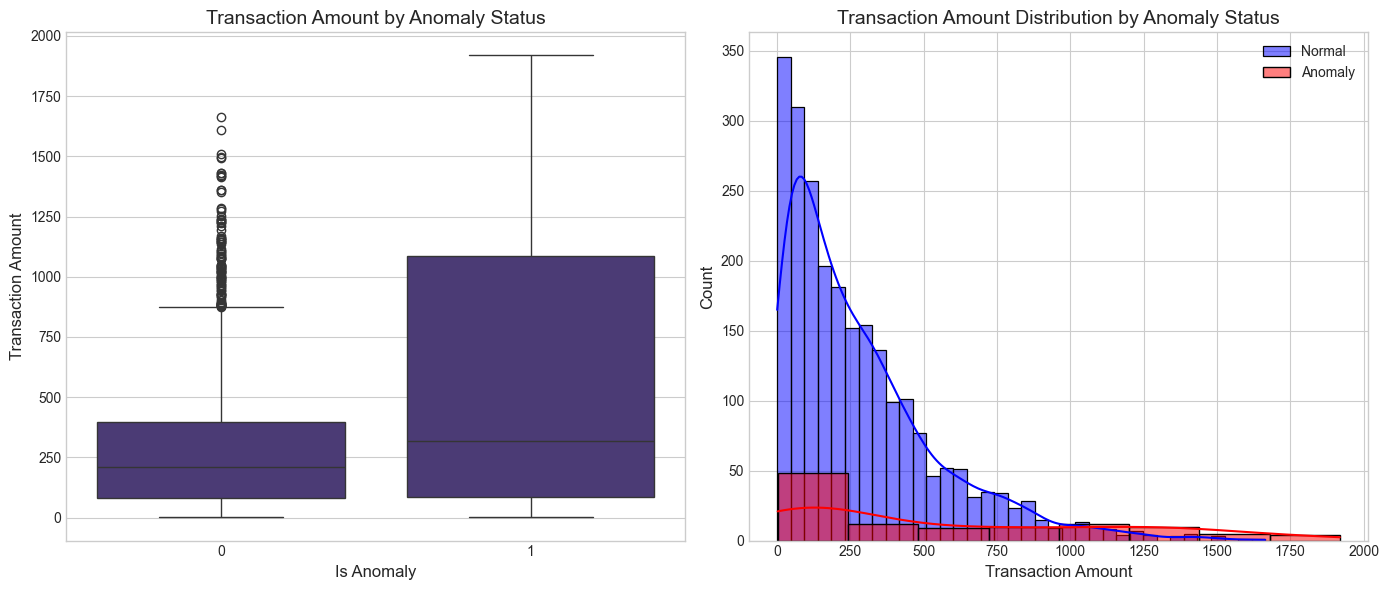

In [48]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='Ensemble_Anomaly', y='TransactionAmount', data=df_model)
plt.title('Transaction Amount by Anomaly Status')
plt.xlabel('Is Anomaly')
plt.ylabel('Transaction Amount')

plt.subplot(1, 2, 2)
sns.histplot(normal['TransactionAmount'], color='blue', alpha=0.5, label='Normal', kde=True)
sns.histplot(anomalies['TransactionAmount'], color='red', alpha=0.5, label='Anomaly', kde=True)
plt.title('Transaction Amount Distribution by Anomaly Status')
plt.xlabel('Transaction Amount')
plt.legend()
plt.tight_layout()
plt.show()

Compare hour of day


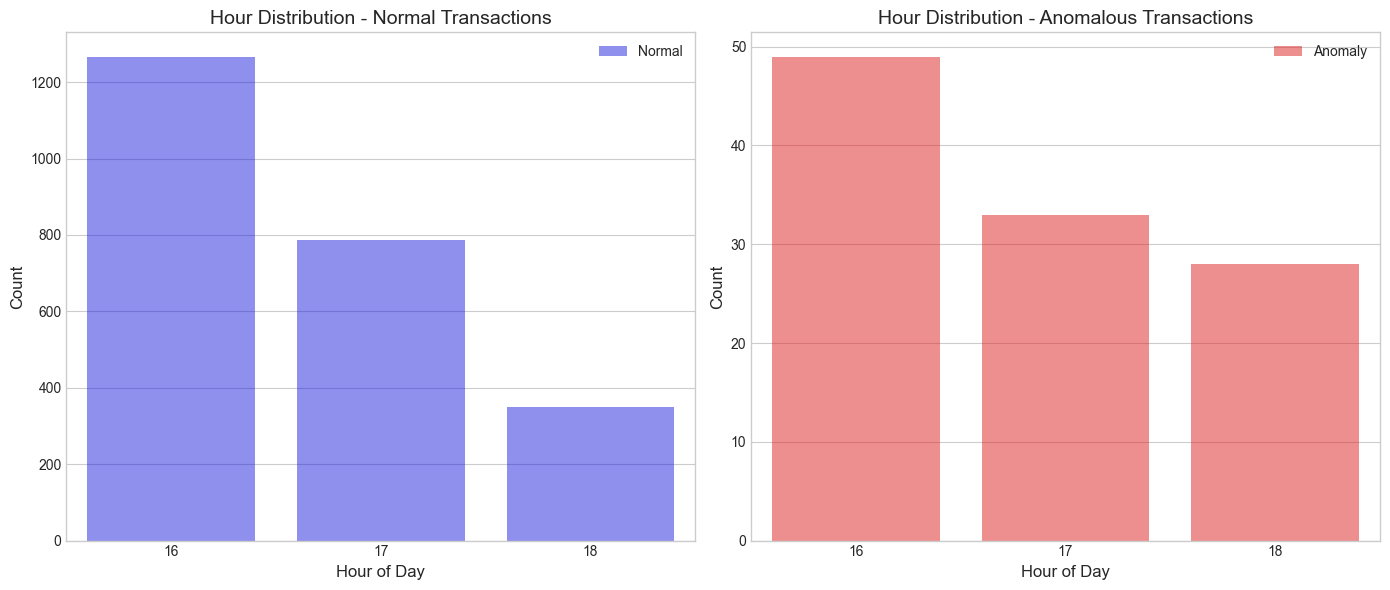

In [49]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='Hour', data=normal, color='blue', alpha=0.5, label='Normal')
plt.title('Hour Distribution - Normal Transactions')
plt.xlabel('Hour of Day')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='Hour', data=anomalies, color='red', alpha=0.5, label='Anomaly')
plt.title('Hour Distribution - Anomalous Transactions')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Compare transaction types

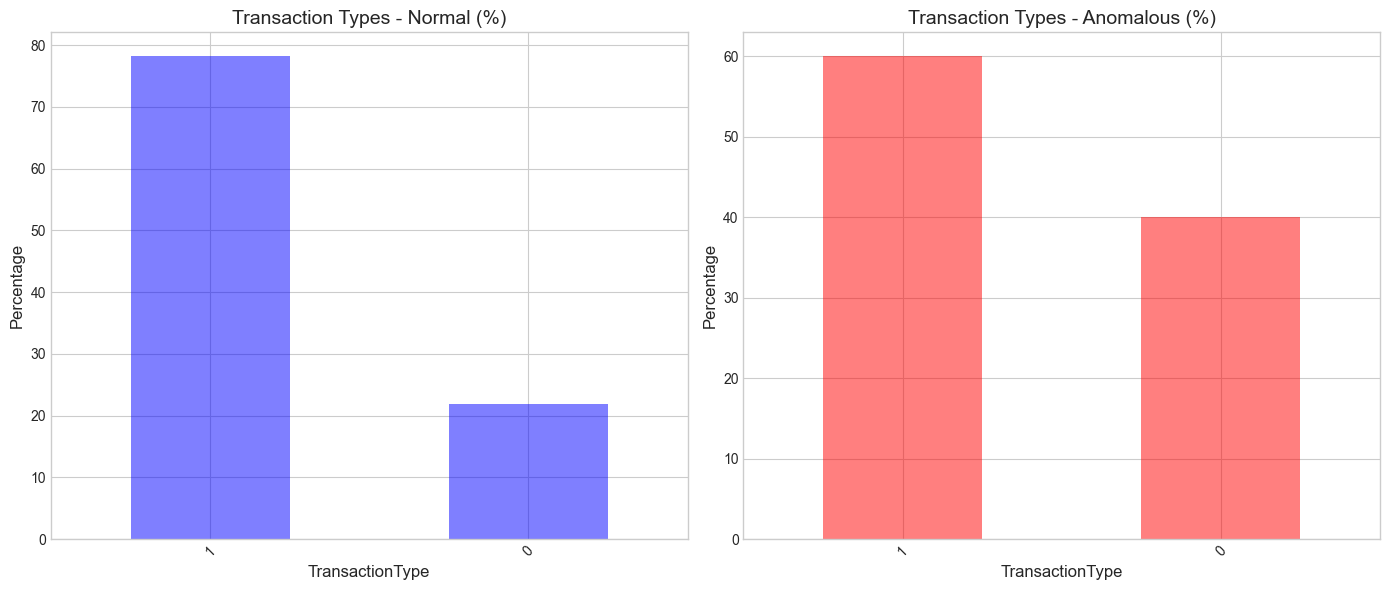

In [50]:
plt.figure(figsize=(14, 6))
normal_tx_type = normal['TransactionType'].value_counts(normalize=True) * 100
anomaly_tx_type = anomalies['TransactionType'].value_counts(normalize=True) * 100

plt.subplot(1, 2, 1)
normal_tx_type.plot(kind='bar', color='blue', alpha=0.5)
plt.title('Transaction Types - Normal (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
anomaly_tx_type.plot(kind='bar', color='red', alpha=0.5)
plt.title('Transaction Types - Anomalous (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Compare channels

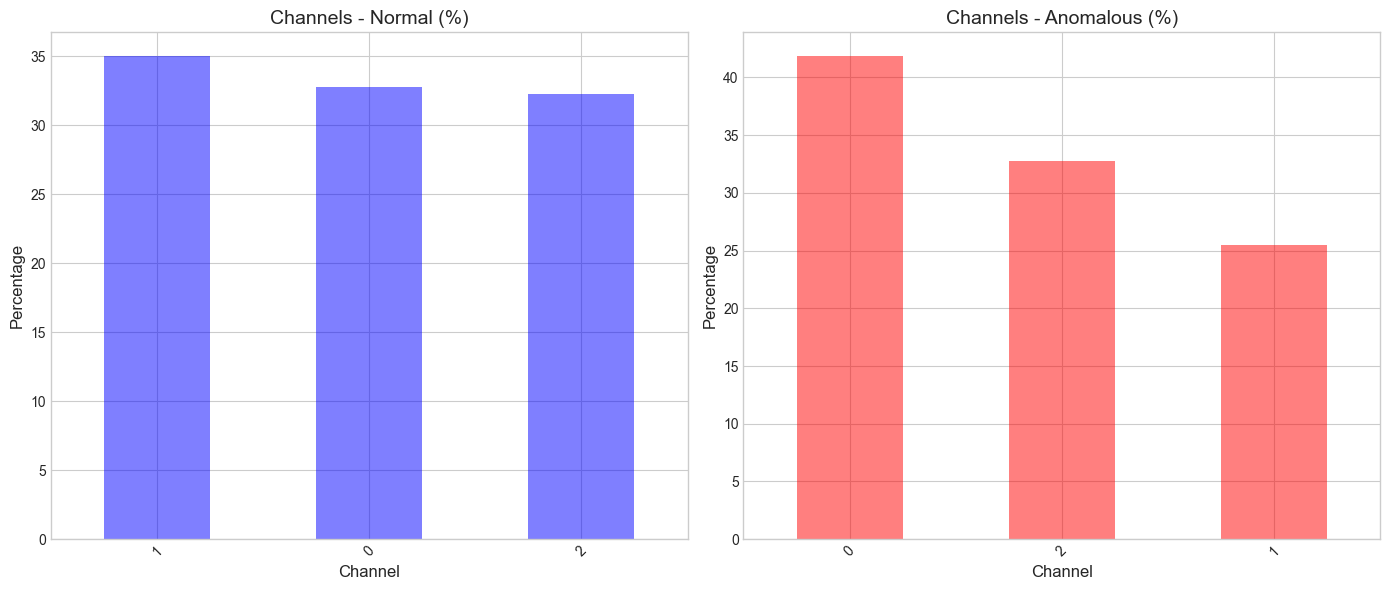

In [51]:
plt.figure(figsize=(14, 6))
normal_channel = normal['Channel'].value_counts(normalize=True) * 100
anomaly_channel = anomalies['Channel'].value_counts(normalize=True) * 100

plt.subplot(1, 2, 1)
normal_channel.plot(kind='bar', color='blue', alpha=0.5)
plt.title('Channels - Normal (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
anomaly_channel.plot(kind='bar', color='red', alpha=0.5)
plt.title('Channels - Anomalous (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Importance

In [52]:
X = df_model.drop(['IF_Anomaly', 'DBSCAN_Label', 'DBSCAN_Anomaly', 'OCSVM_Anomaly', 'IF_Score', 'OCSVM_Score', 'Ensemble_Anomaly'], axis=1)
y = df_model['Ensemble_Anomaly']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

RandomForestClassifier(random_state=42)

Get feature importances

In [53]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop features for distinguishing anomalies:")
print(feature_importances.head(10))


Top features for distinguishing anomalies:
                      Feature  Importance
9               LoginAttempts    0.151848
0           TransactionAmount    0.123181
16  Amount_to_AvgByType_Ratio    0.105878
10             AccountBalance    0.078164
8         TransactionDuration    0.074602
15            TimeSinceLastTx    0.070306
3                    DeviceID    0.065427
2                    Location    0.062681
4                  MerchantID    0.056073
6                 CustomerAge    0.048486


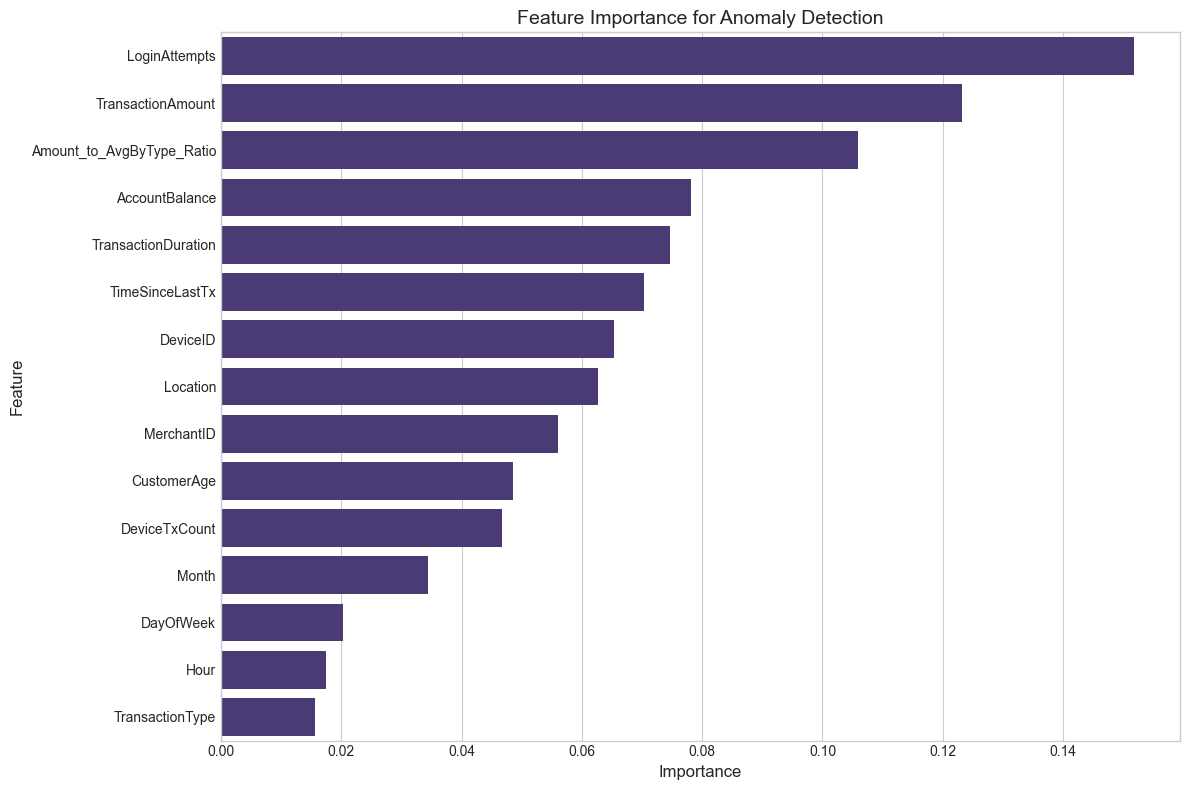

In [54]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15))
plt.title('Feature Importance for Anomaly Detection')
plt.tight_layout()
plt.show()

### Normalize Isolation Forest and One-Class SVM scores to [0,1] scale

For Isolation Forest, lower score means more anomalous

In [55]:
if_scaler = MinMaxScaler()
df_model['IF_Score_Norm'] = if_scaler.fit_transform(-df_model[['IF_Score']])

For One-Class SVM, lower score means more anomalous

In [56]:
ocsvm_scaler = MinMaxScaler()
df_model['OCSVM_Score_Norm'] = ocsvm_scaler.fit_transform(-df_model[['OCSVM_Score']])

Composite score (average of normalized scores)

In [57]:
df_model['Composite_Score'] = (df_model['IF_Score_Norm'] + df_model['OCSVM_Score_Norm']) / 2

Add DBSCAN results (1 for outliers)

In [58]:
df_model['Composite_Score'] = df_model['Composite_Score'] * 0.8 + df_model['DBSCAN_Anomaly'] * 0.2

In [59]:
df_model = df_model.sort_values('Composite_Score', ascending=False)

In [60]:
print("\nTop 20 Most Anomalous Transactions:")
top_anomalies = df_model.head(20).reset_index(drop=True)
print(top_anomalies[['TransactionAmount', 'TransactionType', 'Hour', 'Channel', 'IF_Anomaly', 'DBSCAN_Anomaly', 'OCSVM_Anomaly', 'Ensemble_Anomaly', 'Composite_Score']])


Top 20 Most Anomalous Transactions:
    TransactionAmount  TransactionType  Hour  Channel  IF_Anomaly  \
0             1531.31                1    18        2           1   
1             1192.20                0    16        1           1   
2             1176.28                0    16        0           1   
3             1831.02                0    17        2           1   
4                6.30                1    18        1           1   
5              733.29                1    18        0           1   
6             1168.26                0    16        2           1   
7             1340.19                0    17        2           1   
8             1342.25                0    18        1           1   
9               25.94                0    18        2           1   
10             737.46                0    16        1           1   
11              10.15                1    16        0           1   
12            1392.54                1    16        1           1 

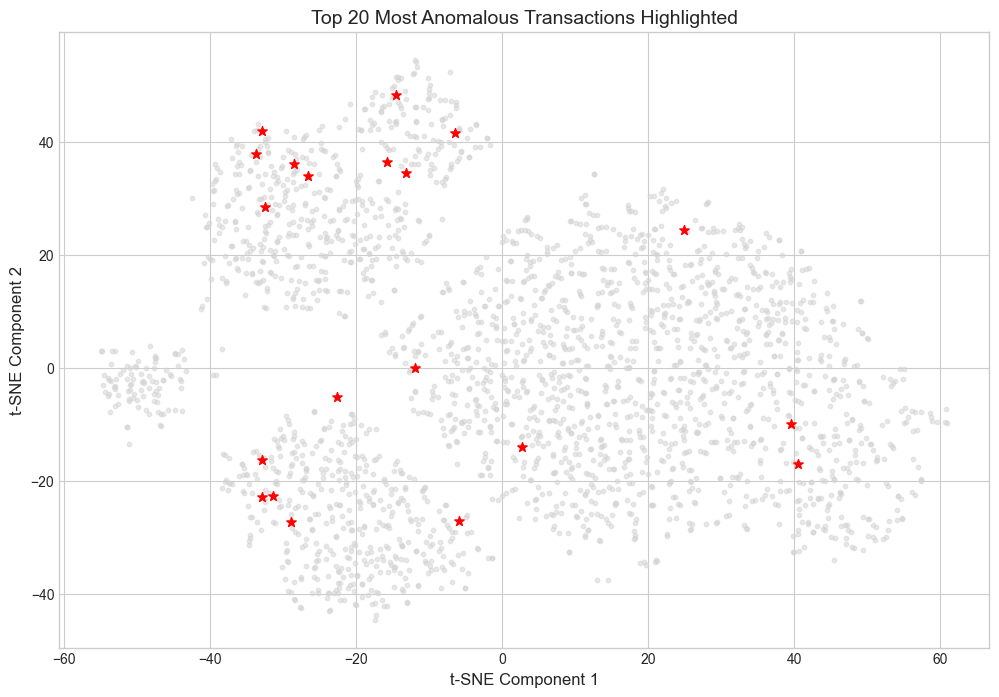

In [61]:
top_indices = top_anomalies.index
plt.figure(figsize=(12, 8))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=10, c='lightgray', alpha=0.5)
plt.scatter(tsne_results[top_indices, 0], tsne_results[top_indices, 1], s=50, c='red', marker='*')
plt.title('Top 20 Most Anomalous Transactions Highlighted')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

## Fraud Patterns And Rules Extraction

Train a decision tree to learn rules that identify anomalies

In [62]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X, y)

DecisionTreeClassifier(max_depth=5, random_state=42)

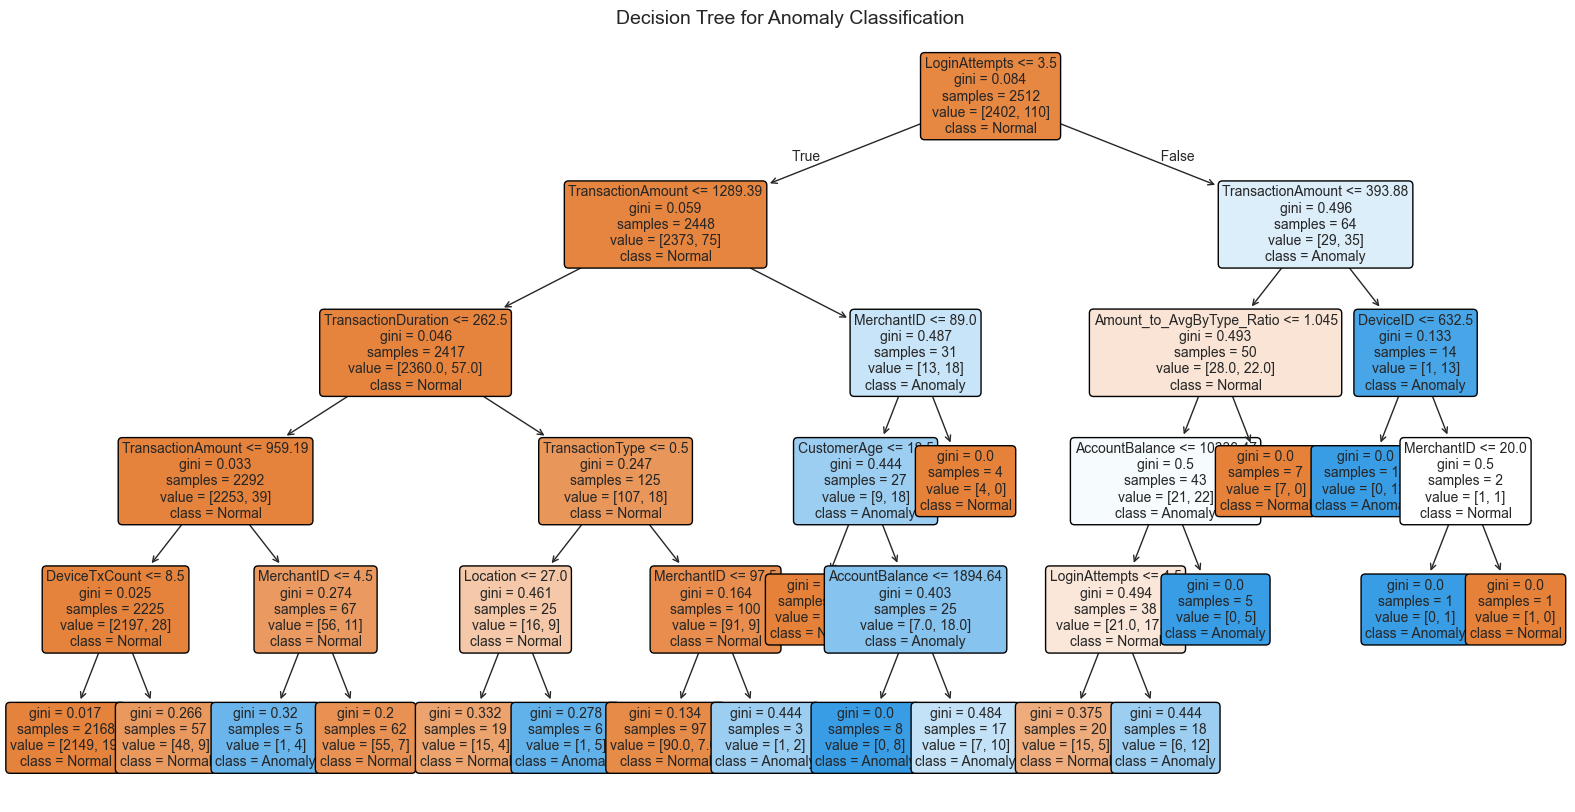

In [63]:
plt.figure(figsize=(20, 10))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=['Normal', 'Anomaly'], rounded=True, fontsize=10)
plt.title('Decision Tree for Anomaly Classification')
plt.show()

In [64]:
print("\nDecision Rules for Identifying Anomalies:")
rules = export_text(dt, feature_names=list(X.columns))
print(rules)


Decision Rules for Identifying Anomalies:
|--- LoginAttempts <= 3.50
|   |--- TransactionAmount <= 1289.39
|   |   |--- TransactionDuration <= 262.50
|   |   |   |--- TransactionAmount <= 959.19
|   |   |   |   |--- DeviceTxCount <= 8.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- DeviceTxCount >  8.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- TransactionAmount >  959.19
|   |   |   |   |--- MerchantID <= 4.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- MerchantID >  4.50
|   |   |   |   |   |--- class: 0
|   |   |--- TransactionDuration >  262.50
|   |   |   |--- TransactionType <= 0.50
|   |   |   |   |--- Location <= 27.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Location >  27.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- TransactionType >  0.50
|   |   |   |   |--- MerchantID <= 97.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- MerchantID >  97.50
|   |   |   |   |   |--- class: 1
|   |--- TransactionAmount >  1289.3

Calculate and print anomaly rate by different segments

In [65]:
print("\nAnomaly Rate by Transaction Type:")
tx_type_anomaly = df_model.groupby('TransactionType')['Ensemble_Anomaly'].mean() * 100
print(tx_type_anomaly.sort_values(ascending=False))

print("\nAnomaly Rate by Hour:")
hour_anomaly = df_model.groupby('Hour')['Ensemble_Anomaly'].mean() * 100
print(hour_anomaly.sort_values(ascending=False))

print("\nAnomaly Rate by Channel:")
channel_anomaly = df_model.groupby('Channel')['Ensemble_Anomaly'].mean() * 100
print(channel_anomaly.sort_values(ascending=False))

print("\nAnomaly Rate by Day of Week:")
dow_anomaly = df_model.groupby('DayOfWeek')['Ensemble_Anomaly'].mean() * 100
print(dow_anomaly.sort_values(ascending=False))


Anomaly Rate by Transaction Type:
TransactionType
0    7.746479
1    3.395062
Name: Ensemble_Anomaly, dtype: float64

Anomaly Rate by Hour:
Hour
18    7.427056
17    4.029304
16    3.723404
Name: Ensemble_Anomaly, dtype: float64

Anomaly Rate by Channel:
Channel
0    5.522209
2    4.438964
1    3.225806
Name: Ensemble_Anomaly, dtype: float64

Anomaly Rate by Day of Week:
DayOfWeek
4    6.702413
0    4.299065
3    4.076087
1    3.611111
2    3.225806
Name: Ensemble_Anomaly, dtype: float64


## Model Performace Evaluation And Comparison

- Here we'd typically use labeled data to evaluate performance
- Since we're using unsupervised learning without ground truth, we'll use:
1. Agreement between models
2. Stability of results

In [66]:
agreement_if_dbscan = (df_model['IF_Anomaly'] == df_model['DBSCAN_Anomaly']).mean() * 100
agreement_if_ocsvm = (df_model['IF_Anomaly'] == df_model['OCSVM_Anomaly']).mean() * 100
agreement_dbscan_ocsvm = (df_model['DBSCAN_Anomaly'] == df_model['OCSVM_Anomaly']).mean() * 100

print("\nModel Agreement Rates:")
print(f"Isolation Forest & DBSCAN: {agreement_if_dbscan:.2f}%")
print(f"Isolation Forest & One-Class SVM: {agreement_if_ocsvm:.2f}%")
print(f"DBSCAN & One-Class SVM: {agreement_dbscan_ocsvm:.2f}%")


Model Agreement Rates:
Isolation Forest & DBSCAN: 75.60%
Isolation Forest & One-Class SVM: 95.54%
DBSCAN & One-Class SVM: 77.83%


In [67]:
avg_agreement = (agreement_if_dbscan + agreement_if_ocsvm + agreement_dbscan_ocsvm) / 3
print(f"Average agreement across all models: {avg_agreement:.2f}%")

Average agreement across all models: 82.99%


Cohen's Kappa for inter-model agreement

In [68]:
kappa_if_dbscan = cohen_kappa_score(df_model['IF_Anomaly'], df_model['DBSCAN_Anomaly'])
kappa_if_ocsvm = cohen_kappa_score(df_model['IF_Anomaly'], df_model['OCSVM_Anomaly'])
kappa_dbscan_ocsvm = cohen_kappa_score(df_model['DBSCAN_Anomaly'], df_model['OCSVM_Anomaly'])

print("\nCohen's Kappa for Model Agreement:")
print(f"Isolation Forest & DBSCAN: {kappa_if_dbscan:.4f}")
print(f"Isolation Forest & One-Class SVM: {kappa_if_ocsvm:.4f}")
print(f"DBSCAN & One-Class SVM: {kappa_dbscan_ocsvm:.4f}")


Cohen's Kappa for Model Agreement:
Isolation Forest & DBSCAN: 0.0595
Isolation Forest & One-Class SVM: 0.2787
DBSCAN & One-Class SVM: 0.2086


In [69]:
avg_kappa = (kappa_if_dbscan + kappa_if_ocsvm + kappa_dbscan_ocsvm) / 3
print(f"Average Kappa across all models: {avg_kappa:.4f}")

Average Kappa across all models: 0.1823


In [70]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for train_idx, test_idx in kf.split(df_scaled):
    # Train models on train set
    train_data = df_scaled[train_idx]
    test_data = df_scaled[test_idx]
    
    # Train Isolation Forest
    iso_cv = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
    iso_cv.fit(train_data)
    iso_preds = iso_cv.predict(test_data)
    iso_preds = np.where(iso_preds == -1, 1, 0)  # Convert to binary (1 for anomaly)
    
    # Train DBSCAN
    dbscan_cv = DBSCAN(eps=best_eps if best_eps else 2.5, min_samples=best_min_samples if best_min_samples else 10)
    dbscan_labels = dbscan_cv.fit_predict(train_data)
    # Use a nearest neighbors approach to predict test set
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(train_data[dbscan_labels != -1])  # Fit only on non-outlier points
    
    # For each test point, find distance to nearest non-outlier in training set
    distances, _ = nn.kneighbors(test_data)
    dbscan_preds = np.zeros(len(test_data))
    dbscan_preds[distances.flatten() > best_eps if best_eps else 2.5] = 1  # Mark as anomaly if distance > eps
    
    # Train One-Class SVM
    ocsvm_cv = OneClassSVM(nu=0.05, kernel="rbf", gamma='auto')
    ocsvm_cv.fit(train_data)
    ocsvm_preds = ocsvm_cv.predict(test_data)
    ocsvm_preds = np.where(ocsvm_preds == -1, 1, 0)  # Convert to binary (1 for anomaly)
    
    # Calculate anomaly rates for each model
    iso_rate = np.mean(iso_preds)
    dbscan_rate = np.mean(dbscan_preds)
    ocsvm_rate = np.mean(ocsvm_preds)
    
    cv_results.append({
        'IF_Rate': iso_rate,
        'DBSCAN_Rate': dbscan_rate,
        'OCSVM_Rate': ocsvm_rate
    })

In [71]:
cv_results_df = pd.DataFrame(cv_results)
print("\nStability of anomaly detection rates across folds:")
print(cv_results_df)
print("\nMean and standard deviation of anomaly rates:")
print(cv_results_df.mean())
print(cv_results_df.std())


Stability of anomaly detection rates across folds:
    IF_Rate  DBSCAN_Rate  OCSVM_Rate
0  0.021869     0.155070    0.093439
1  0.013917     0.155070    0.057654
2  0.019920     0.177291    0.087649
3  0.027888     0.165339    0.065737
4  0.025896     0.177291    0.083665

Mean and standard deviation of anomaly rates:
IF_Rate        0.021898
DBSCAN_Rate    0.166012
OCSVM_Rate     0.077629
dtype: float64
IF_Rate        0.005466
DBSCAN_Rate    0.011117
OCSVM_Rate     0.015225
dtype: float64


In [72]:
stability_score = 1 - cv_results_df.std().mean()
print(f"Overall stability score (higher is better): {stability_score:.4f}")

Overall stability score (higher is better): 0.9894


Train LOF model

In [73]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
df_model['LOF_Anomaly'] = lof.fit_predict(df_scaled)
df_model['LOF_Score'] = -lof.negative_outlier_factor_

In [74]:
df_model['LOF_Anomaly'] = df_model['LOF_Anomaly'].map({1: 0, -1: 1})

print(f"LOF Anomalies: {df_model['LOF_Anomaly'].sum()} ({df_model['LOF_Anomaly'].mean()*100:.2f}%)")

LOF Anomalies: 51 (2.03%)


Update ensemble with LOF

In [75]:
df_model['Ensemble_Anomaly_v2'] = ((df_model['IF_Anomaly'] + df_model['DBSCAN_Anomaly'] + 
                                 df_model['OCSVM_Anomaly'] + df_model['LOF_Anomaly']) >= 2).astype(int)
print(f"Updated Ensemble Anomalies (≥2 models): {df_model['Ensemble_Anomaly_v2'].sum()} ({df_model['Ensemble_Anomaly_v2'].mean()*100:.2f}%)")

Updated Ensemble Anomalies (≥2 models): 122 (4.86%)


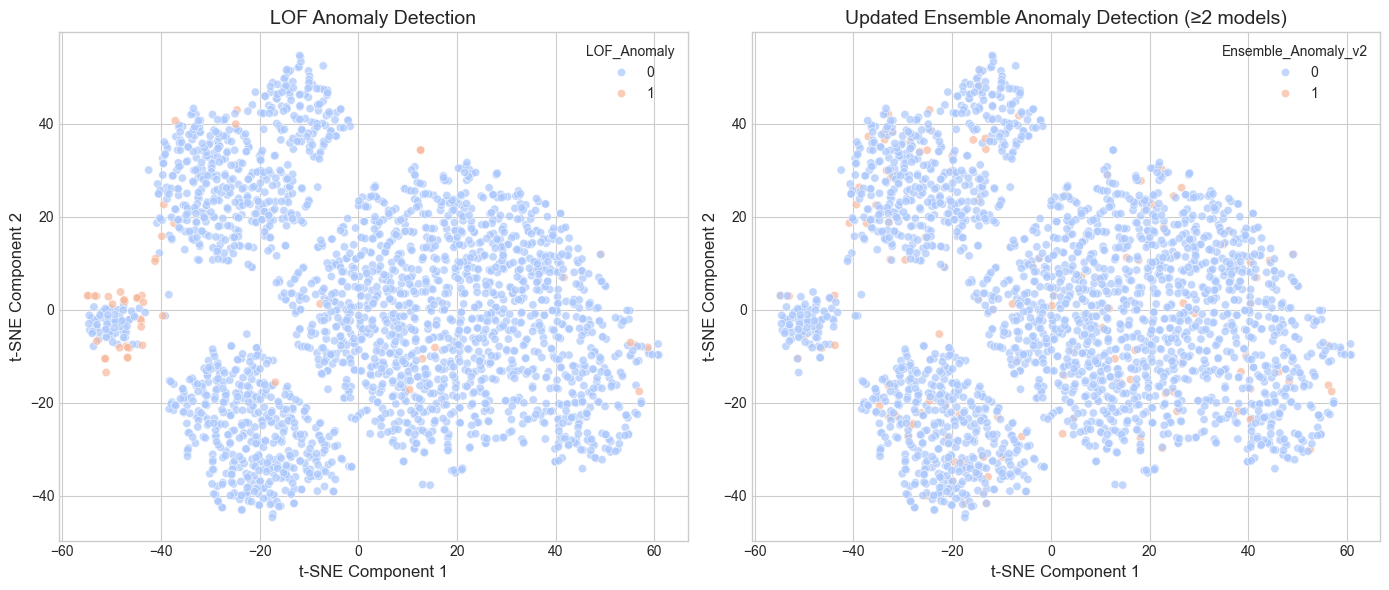

In [76]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=df_model['LOF_Anomaly'], palette='coolwarm', alpha=0.7)
plt.title('LOF Anomaly Detection')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.subplot(1, 2, 2)
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=df_model['Ensemble_Anomaly_v2'], palette='coolwarm', alpha=0.7)
plt.title('Updated Ensemble Anomaly Detection (≥2 models)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

## Advanced Features Engineering

In [77]:
df_advanced = df_eda.copy()

### 1. Transaction velocity features


In [78]:
if "AccountID" in df.columns:
    # Group by AccountID
    account_groups = df_advanced.groupby("AccountID")
    
    # Number of transactions per account
    account_tx_count = account_groups.size().reset_index(name='AccountTxCount')
    df_advanced = pd.merge(df_advanced, account_tx_count, on='AccountID', how='left')
    
    # Average transaction amount per account
    account_avg_amount = account_groups['TransactionAmount'].mean().reset_index(name='AccountAvgAmount')
    df_advanced = pd.merge(df_advanced, account_avg_amount, on='AccountID', how='left')
    
    # Standard deviation of transaction amounts per account
    account_std_amount = account_groups['TransactionAmount'].std().reset_index(name='AccountStdAmount')
    df_advanced = pd.merge(df_advanced, account_std_amount, on='AccountID', how='left')
    # Fill NaN values (accounts with only one transaction)
    df_advanced['AccountStdAmount'].fillna(0, inplace=True)
    
    # Ratio of current transaction to account average
    df_advanced['TxToAccountAvgRatio'] = df_advanced['TransactionAmount'] / df_advanced['AccountAvgAmount']
    # Handle potential division by zero
    df_advanced['TxToAccountAvgRatio'].replace([np.inf, -np.inf], np.nan, inplace=True)
    df_advanced['TxToAccountAvgRatio'].fillna(1, inplace=True)
    
    # Time-based features if we have the data
    if 'PreviousTransactionDate' in df.columns and 'TransactionDate' in df_advanced.columns:
        # Sort transactions by account and date
        df_advanced = df_advanced.sort_values(['AccountID', 'TransactionDate'])
        
        # Calculate time differences between consecutive transactions for the same account
        df_advanced['PrevTxDate'] = df_advanced.groupby('AccountID')['TransactionDate'].shift(1)
        df_advanced['TimeSinceLastTx'] = (df_advanced['TransactionDate'] - df_advanced['PrevTxDate']).dt.total_seconds() / 3600
        
        # Fill NaN values (first transactions)
        df_advanced['TimeSinceLastTx'].fillna(df_advanced['TimeSinceLastTx'].median(), inplace=True)
        
        # Calculate transaction velocity (transactions per day)
        account_velocity = account_groups.apply(
            lambda x: len(x) / ((x['TransactionDate'].max() - x['TransactionDate'].min()).total_seconds() / 86400)
            if len(x) > 1 else 0
        ).reset_index(name='AccountTxVelocity')
        df_advanced = pd.merge(df_advanced, account_velocity, on='AccountID', how='left')
        
        # Handle accounts with only one transaction
        df_advanced['AccountTxVelocity'].fillna(0, inplace=True)

### 2. Location and device-based features


In [79]:
if 'Location' in df_advanced.columns:
    # Count of distinct locations per account
    if 'AccountID' in df.columns:
        account_location_count = df_advanced.groupby('AccountID')['Location'].nunique().reset_index(name='AccountLocationCount')
        df_advanced = pd.merge(df_advanced, account_location_count, on='AccountID', how='left')
    
    # Location rarity (how uncommon is this location in the dataset)
    location_counts = df_advanced['Location'].value_counts()
    location_rarity = 1 / location_counts
    df_advanced['LocationRarity'] = df_advanced['Location'].map(location_rarity)

if 'DeviceID' in df_advanced.columns:
    # Count of distinct devices per account
    if 'AccountID' in df.columns:
        account_device_count = df_advanced.groupby('AccountID')['DeviceID'].nunique().reset_index(name='AccountDeviceCount')
        df_advanced = pd.merge(df_advanced, account_device_count, on='AccountID', how='left')
    
    # Device rarity
    device_counts = df_advanced['DeviceID'].value_counts()
    device_rarity = 1 / device_counts
    df_advanced['DeviceRarity'] = df_advanced['DeviceID'].map(device_rarity)

### 3. Behavioral pattern features


In [80]:
if 'Hour' in df_advanced.columns and 'AccountID' in df.columns:
    # Get modal hour for each account
    account_modal_hour = df_advanced.groupby('AccountID')['Hour'].agg(
        lambda x: x.value_counts().index[0] if len(x) > 0 else -1
    ).reset_index(name='AccountModalHour')
    df_advanced = pd.merge(df_advanced, account_modal_hour, on='AccountID', how='left')
    
    # Calculate hour difference from typical behavior
    df_advanced['HourDeviation'] = abs(df_advanced['Hour'] - df_advanced['AccountModalHour'])
    # Wrap around for hour (e.g., difference between 23 and 1 should be 2, not 22)
    df_advanced['HourDeviation'] = df_advanced['HourDeviation'].apply(lambda x: min(x, 24-x))

### Combine all features for advanced modeling

In [81]:
# Drop columns that shouldn't be used in modeling
cols_to_drop = ['TransactionDate', 'PreviousTransactionDate', 'PrevTxDate', 'Amount_Z_Score']
advanced_features = df_advanced.drop([col for col in cols_to_drop if col in df_advanced.columns], axis=1)

In [82]:
# Convert remaining categorical columns to numerical
categorical_cols = advanced_features.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    advanced_features[col] = LabelEncoder().fit_transform(advanced_features[col])

print(f"Number of features after engineering: {advanced_features.shape[1]}")
print(f"New features added: {set(advanced_features.columns) - set(df_model.columns)}")

Number of features after engineering: 30
New features added: {'AccountAvgAmount', 'TransactionID', 'AccountLocationCount', 'TxToAccountAvgRatio', 'HourDeviation', 'AccountID', 'AccountModalHour', 'AccountStdAmount', 'IP Address', 'DeviceRarity', 'AccountTxCount', 'AccountDeviceCount', 'LocationRarity', 'AccountTxVelocity'}


In [83]:
# Scale the advanced features
advanced_scaler = StandardScaler()
advanced_scaled = advanced_scaler.fit_transform(advanced_features)

## Advanced Modeling With New Features

Apply Isolation Forest with advanced features

In [84]:
iso_advanced = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
advanced_features['IF_Advanced_Anomaly'] = iso_advanced.fit_predict(advanced_scaled)
advanced_features['IF_Advanced_Score'] = iso_advanced.decision_function(advanced_scaled)
advanced_features['IF_Advanced_Anomaly'] = advanced_features['IF_Advanced_Anomaly'].map({1: 0, -1: 1})

print(f"Advanced Isolation Forest Anomalies: {advanced_features['IF_Advanced_Anomaly'].sum()} ({advanced_features['IF_Advanced_Anomaly'].mean()*100:.2f}%)")

Advanced Isolation Forest Anomalies: 51 (2.03%)


## Apply t-SNE for visualization

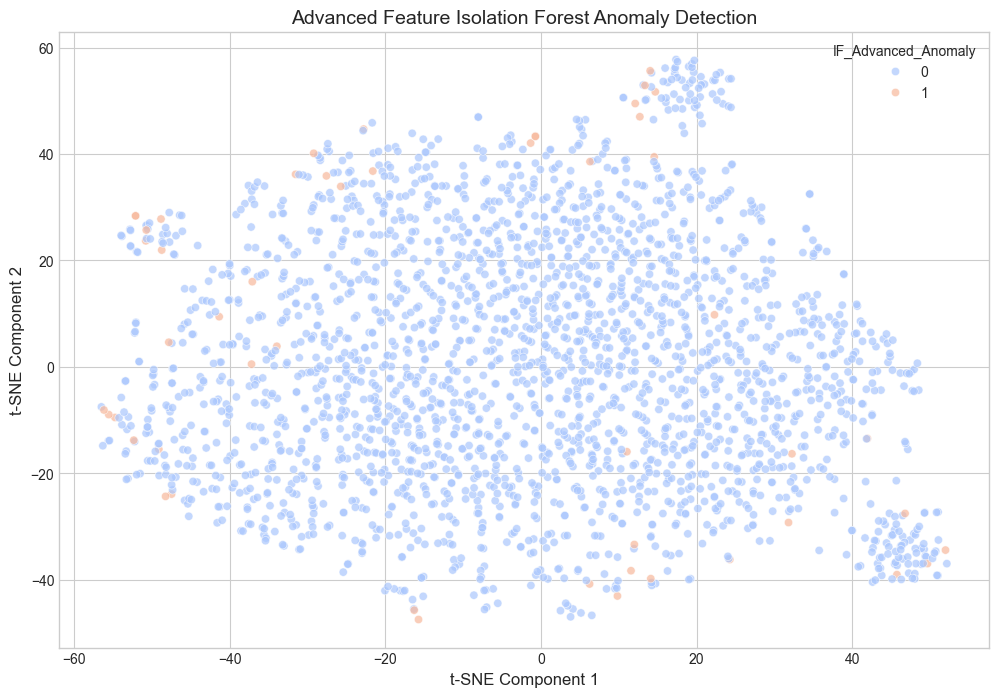

In [85]:
tsne_advanced = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results_advanced = tsne_advanced.fit_transform(advanced_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=tsne_results_advanced[:, 0], y=tsne_results_advanced[:, 1], 
                hue=advanced_features['IF_Advanced_Anomaly'], palette='coolwarm', alpha=0.7)
plt.title('Advanced Feature Isolation Forest Anomaly Detection')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

Feature importance for advanced anomaly detection

In [86]:
X_advanced = advanced_features.drop(['IF_Advanced_Anomaly', 'IF_Advanced_Score'], axis=1)
y_advanced = advanced_features['IF_Advanced_Anomaly']

rf_advanced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_advanced.fit(X_advanced, y_advanced)

RandomForestClassifier(random_state=42)

Get feature importances


Top features for distinguishing anomalies with advanced features:
                 Feature  Importance
2      TransactionAmount    0.073410
18       TimeSinceLastTx    0.063573
0          TransactionID    0.054744
23     AccountTxVelocity    0.053833
21      AccountStdAmount    0.047708
22   TxToAccountAvgRatio    0.046960
13        AccountBalance    0.045495
20      AccountAvgAmount    0.045238
25        LocationRarity    0.045009
27          DeviceRarity    0.041353
6             IP Address    0.037116
28      AccountModalHour    0.036713
19        AccountTxCount    0.036704
1              AccountID    0.036512
24  AccountLocationCount    0.035342


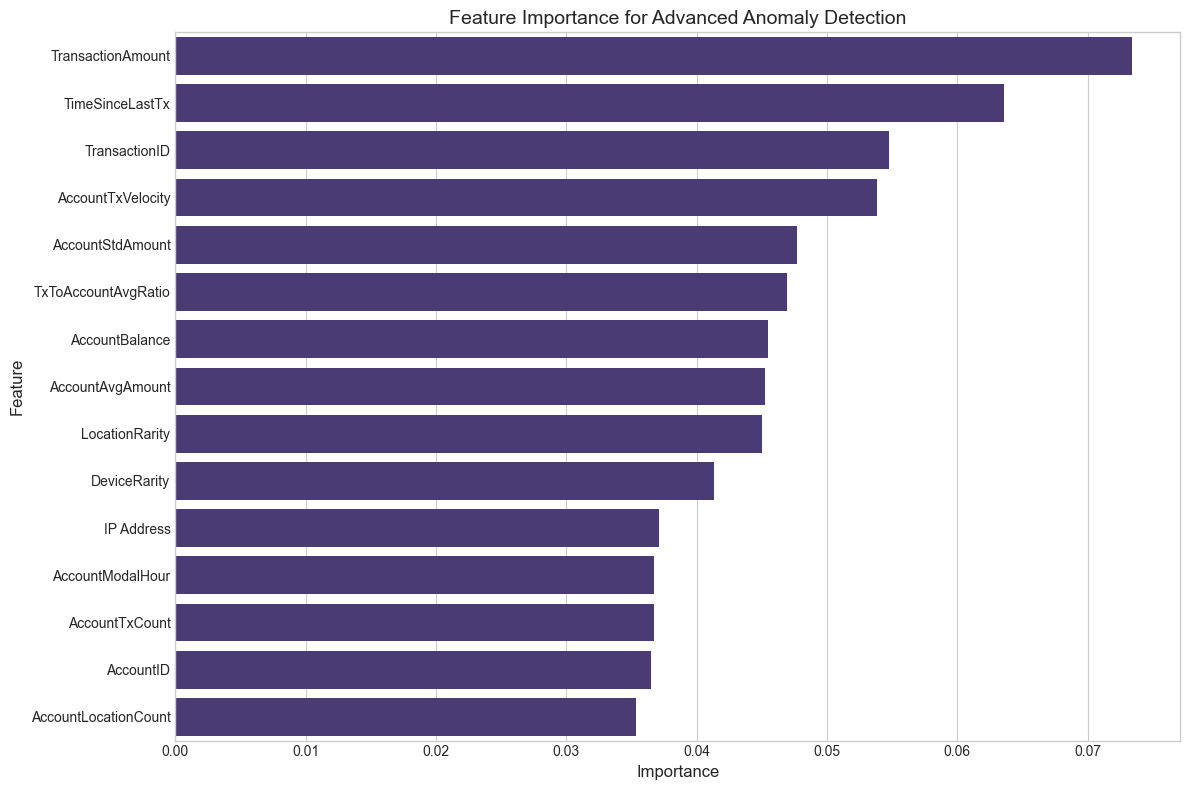

In [87]:
advanced_importances = pd.DataFrame({
    'Feature': X_advanced.columns,
    'Importance': rf_advanced.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop features for distinguishing anomalies with advanced features:")
print(advanced_importances.head(15))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=advanced_importances.head(15))
plt.title('Feature Importance for Advanced Anomaly Detection')
plt.tight_layout()
plt.show()

## Clustering-Based Analysis

Optimum number of clusters using elbow method

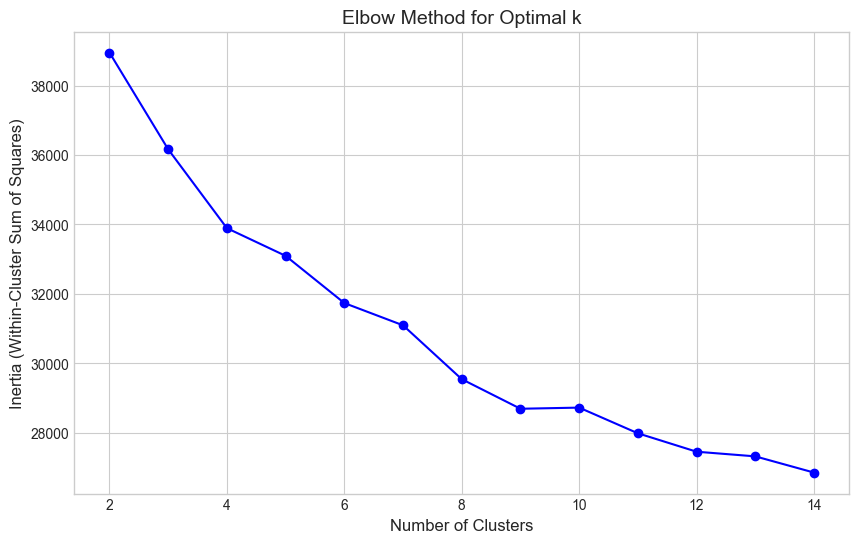

In [88]:
inertia = []
k_range = range(2, 15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [144]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_model['Cluster'] = kmeans.fit_predict(df_scaled)

print(f"\nCluster distribution:")
print(df_model['Cluster'].value_counts())


Cluster distribution:
Cluster
0    832
1    801
3    591
2    288
Name: count, dtype: int64


In [145]:
silhouette_avg = silhouette_score(df_scaled, df_model['Cluster'])
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.0934


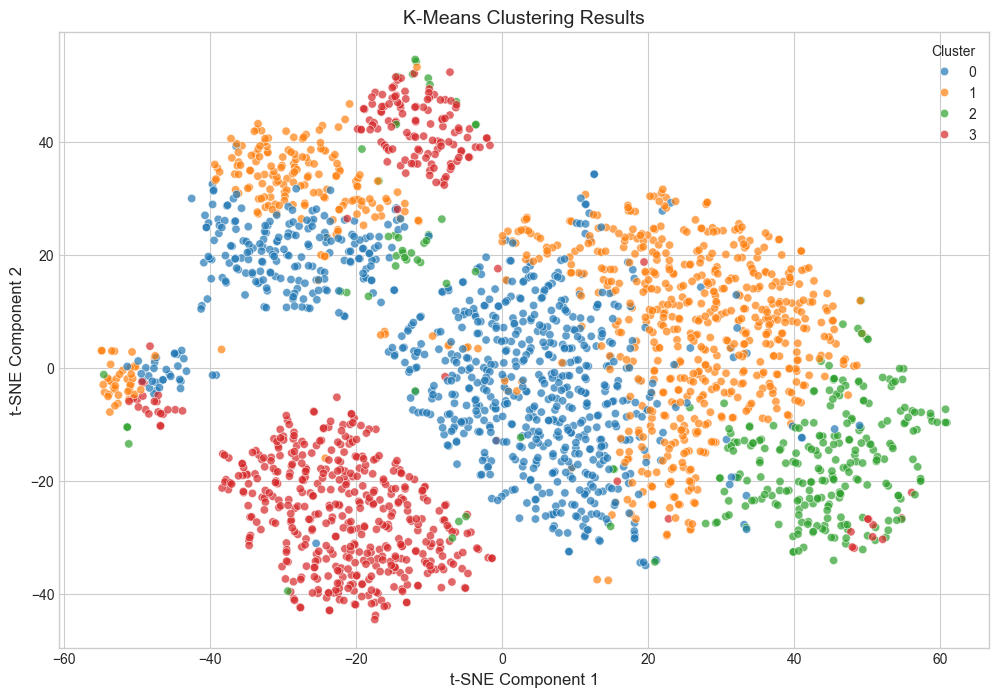

In [146]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], 
                hue=df_model['Cluster'], palette='tab10', alpha=0.7)
plt.title('K-Means Clustering Results')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

Analyze anomaly distribution across clusters


Anomaly percentage by cluster:
Ensemble_Anomaly_v2          0         1
Cluster                                 
0                    95.793269  4.206731
1                    95.006242  4.993758
2                    94.791667  5.208333
3                    94.585448  5.414552


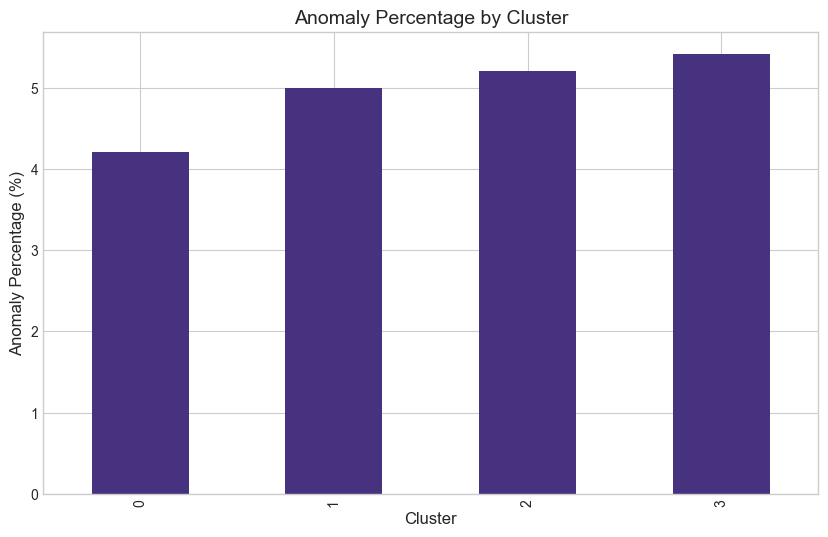

In [147]:
cluster_anomaly = pd.crosstab(df_model['Cluster'], df_model['Ensemble_Anomaly_v2'], 
                              normalize='index') * 100
print("\nAnomaly percentage by cluster:")
print(cluster_anomaly)

plt.figure(figsize=(10, 6))
cluster_anomaly[1].sort_values().plot(kind='bar')
plt.title('Anomaly Percentage by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Anomaly Percentage (%)')
plt.grid(True, axis='y')
plt.show()

Analyze cluster characteristics

In [148]:
cluster_profiles = df_model.groupby('Cluster').agg({
    'TransactionAmount': ['mean', 'std', 'min', 'max'],
    'Hour': 'mean',
    'Weekend': 'mean',
    'TransactionType': 'mean',
    'Channel': 'mean',
    'Ensemble_Anomaly_v2': 'mean'
})

print("\nCluster profiles:")
print(cluster_profiles)


Cluster profiles:
        TransactionAmount                                  Hour Weekend  \
                     mean         std   min      max       mean    mean   
Cluster                                                                   
0              307.085240  293.706356  0.84  1762.28  16.634615     0.0   
1              299.884494  298.982721  0.45  1664.33  16.639201     0.0   
2              289.273785  296.797538  0.32  1454.52  16.611111     0.0   
3              285.181591  277.244369  0.26  1919.11  16.604061     0.0   

        TransactionType   Channel Ensemble_Anomaly_v2  
                   mean      mean                mean  
Cluster                                                
0              0.780048  0.989183            0.042067  
1              0.765293  1.036205            0.049938  
2              0.791667  0.909722            0.052083  
3              0.768190  0.972927            0.054146  


## Time Series Analysis of Anomalies

Merge anomaly results back to original data with dates

In [94]:
df_time = df_eda.copy()
df_time['Anomaly'] = df_model['Ensemble_Anomaly_v2'].values

Group by date and calculate daily anomaly rate

In [95]:
df_time['Date'] = df_time['TransactionDate'].dt.date
daily_anomaly = df_time.groupby('Date').agg({
    'Anomaly': 'mean',
    'TransactionID': 'count'
}).reset_index()
daily_anomaly.columns = ['Date', 'AnomalyRate', 'TransactionCount']
daily_anomaly['AnomalyRate'] = daily_anomaly['AnomalyRate'] * 100

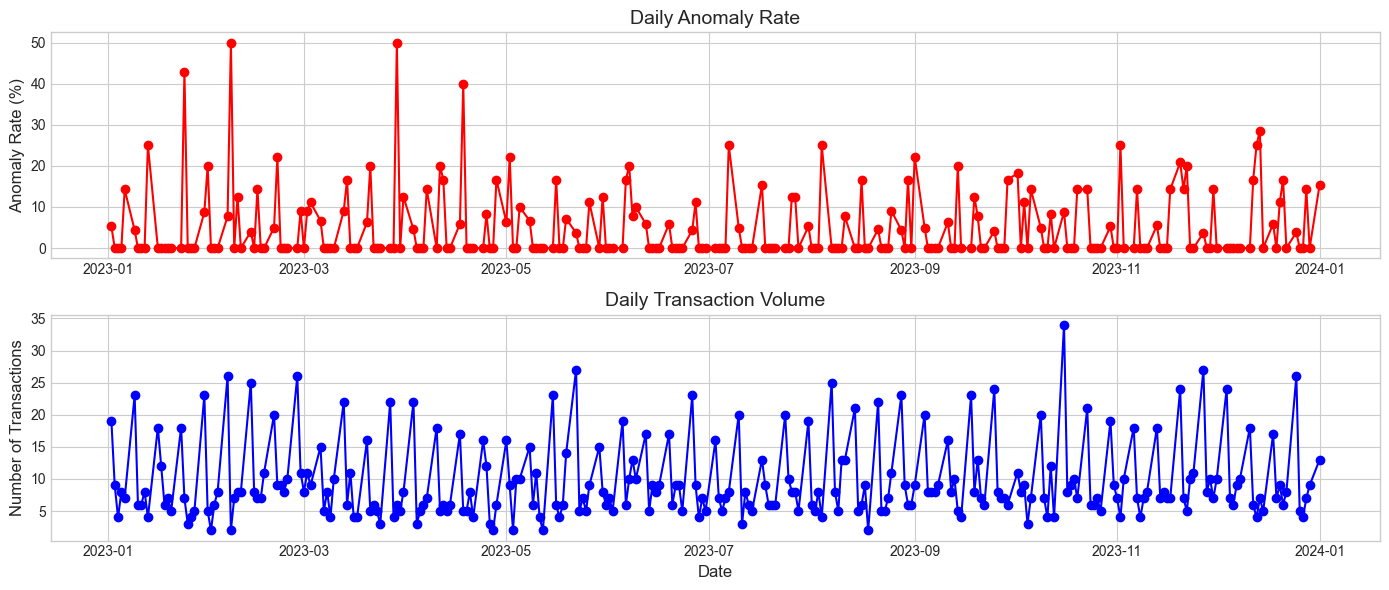

In [96]:
# Plot anomaly rate over time
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(daily_anomaly['Date'], daily_anomaly['AnomalyRate'], 'ro-')
plt.title('Daily Anomaly Rate')
plt.ylabel('Anomaly Rate (%)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(daily_anomaly['Date'], daily_anomaly['TransactionCount'], 'bo-')
plt.title('Daily Transaction Volume')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()

Analyze hourly patterns of anomalies

In [97]:
hourly_anomaly = df_time.groupby('Hour').agg({
    'Anomaly': 'mean',
    'TransactionID': 'count'
}).reset_index()
hourly_anomaly.columns = ['Hour', 'AnomalyRate', 'TransactionCount']
hourly_anomaly['AnomalyRate'] = hourly_anomaly['AnomalyRate'] * 100  

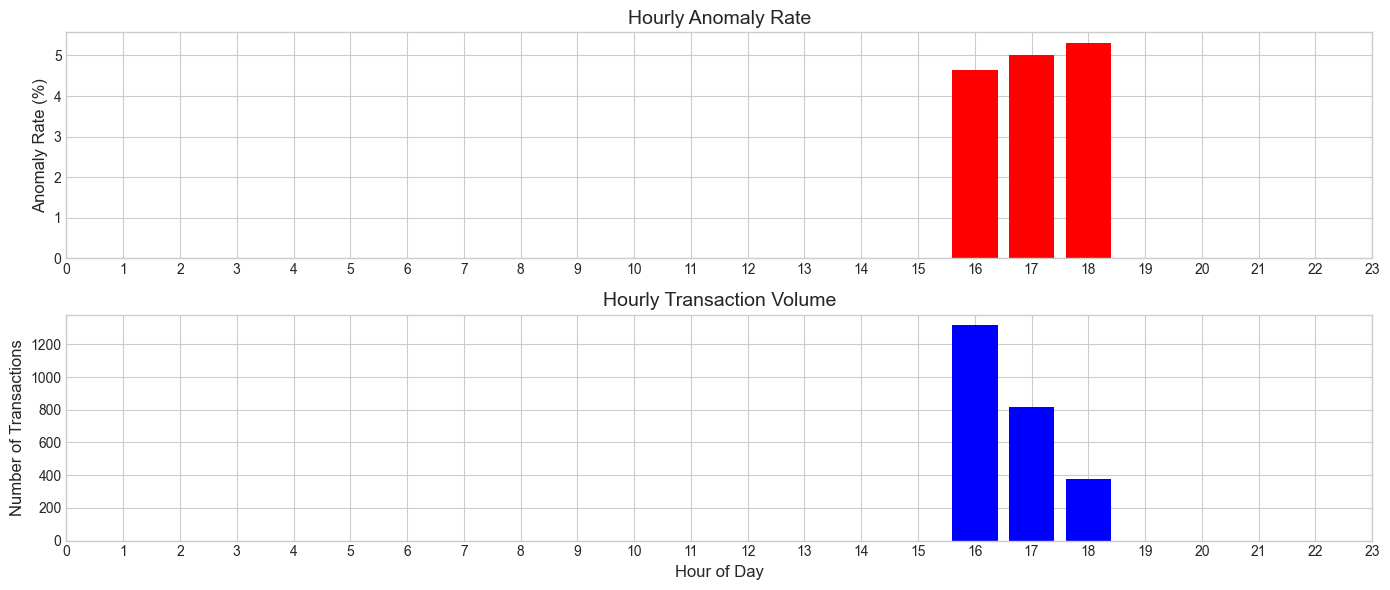

In [98]:
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.bar(hourly_anomaly['Hour'], hourly_anomaly['AnomalyRate'], color='r')
plt.title('Hourly Anomaly Rate')
plt.ylabel('Anomaly Rate (%)')
plt.grid(True, axis='y')
plt.xticks(range(0, 24))

plt.subplot(2, 1, 2)
plt.bar(hourly_anomaly['Hour'], hourly_anomaly['TransactionCount'], color='b')
plt.title('Hourly Transaction Volume')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.grid(True, axis='y')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## Conclusion and Recommendation

#### Fraud Detection System Summary:
-------------------------------
1. Data Exploration:
   - Analyzed transaction patterns by time, amount, type, and channel
   - Identified initial data characteristics and potential anomalies

2. Feature Engineering:
   - Created time-based features (hour, day, weekend flag)
   - Engineered behavioral features (deviation from typical patterns)
   - Added transaction velocity and pattern-based features

3. Modeling Approach:
   - Applied multiple unsupervised algorithms (Isolation Forest, DBSCAN, One-Class SVM, LOF)
   - Created ensemble model combining multiple algorithm outputs
   - Implemented cluster analysis to identify transaction segments

4. Anomaly Characterization:
   - Identified key features distinguishing anomalies from normal transactions
   - Analyzed temporal patterns of anomalies
   - Created comprehensive risk scoring system

In [99]:
# Top anomaly indicators
print("\nTop anomaly indicators:")
for idx, row in feature_importances.head(5).iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")


Top anomaly indicators:
- LoginAttempts: 0.1518
- TransactionAmount: 0.1232
- Amount_to_AvgByType_Ratio: 0.1059
- AccountBalance: 0.0782
- TransactionDuration: 0.0746


In [100]:
# High-risk time periods
high_risk_hours = hourly_anomaly.sort_values('AnomalyRate', ascending=False).head(3)
print("\nHighest risk hours:")
for _, row in high_risk_hours.iterrows():
    print(f"- Hour {int(row['Hour'])}: {row['AnomalyRate']:.2f}% anomaly rate")


Highest risk hours:
- Hour 18: 5.31% anomaly rate
- Hour 17: 5.01% anomaly rate
- Hour 16: 4.64% anomaly rate
